# Week 7: From Baselines to Targeted Experiments

**UHPC 28-day compressive strength prediction**  
**Model family:** Linear Family models only  
**Dataset policy:** Shoaib's semantic-recoded 50 percent policy

## 1. Current Week 7 Setup

In Week 6, the Linear Family track worked with semantic-missingness strategies from our own UHPC raw dataset. For Week 7, we have decided: everyone should use the Shoaib's semantic-recoded dataset under `S2_Kernel`, specifically the **50 percent feature policy**.

That means the old feature-policy experiment (`full_raw` vs `raw_le_50` vs `raw_le_20`) is not a targeted experiment this week. I kept the helper function available in the code, but the runner intentionally skips it. The useful Week 7 questions are instead:

- Can fixed Linear Family models give a defendable baseline on 50 percent dataset?
- Do errors change by strength range, curing regime, or fiber usage?
- Are fiber features actually useful for 28-day compressive strength prediction?
- What happens if target outliers are removed only from training?
- Do simple concrete engineering ratios help, or do they add redundant information?
- Is numeric multicollinearity strong enough to make OLS coefficient interpretation risky?

The last question uses VIF, but VIF is a diagnostic for coefficient stability, not a model-performance metric.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)


def find_project_root() -> Path:
    """Find S1_Linear whether the notebook is run from the repo root or notebooks/."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "reports" / "tables").exists() and (candidate / "src" / "s1_linear").exists():
            return candidate
    raise RuntimeError("Could not find the S1_Linear project root.")


PROJECT_ROOT = find_project_root()
TABLES = PROJECT_ROOT / "reports" / "tables"
FIGURES = PROJECT_ROOT / "reports" / "figures" / "week07"


def load_table(name: str) -> pd.DataFrame:
    return pd.read_csv(TABLES / name)


def show_figure(name: str, width: int = 980) -> None:
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"Missing figure: {path}")


def rounded(df: pd.DataFrame, digits: int = 3) -> pd.DataFrame:
    return df.round(digits)


print(f"Project root: {PROJECT_ROOT}")
print(f"Tables: {TABLES}")
print(f"Figures: {FIGURES}")

Project root: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear
Tables: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables
Figures: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/figures/week07


## 2. Dataset Lineage and Readiness

The source dataset is a semantic-recoded UHPC dataset. It is important to say this carefully: the  dataset was **semantically recoded**, but it was **not scaled or one-hot encoded**. Therefore our Linear Family pipeline still has to do numerical imputation, scaling, missing indicators, and categorical encoding.

The S1 import step creates an S1-owned copy so our workflow does not modify or depend on editing the teammate directory. This is the cleaner choice for reproducibility: the source remains traceable, while the Linear Family track owns its modeling-ready input.

In [2]:
import_audit = load_table("week07_teammate_import_audit_summary.csv")
readiness = load_table("week07_teammate_import_readiness.csv")
split_summary = load_table("week07_semantic_50_split_summary.csv")
preprocessing_summary = load_table("week07_semantic_50_preprocessing_summary.csv")

display(import_audit[import_audit["item"].isin([
    "canonical_source_path",
    "source_rows",
    "output_rows",
    "output_columns",
    "columns_dropped",
    "exact_duplicate_rows_removed",
    "numeric_predictors",
    "categorical_predictors",
    "policy",
])])
display(readiness)
display(rounded(split_summary))
display(preprocessing_summary)

,item,value,detail
0,canonical_source_path,/Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S2_Kernel/Datasets/processed/uhpc_dataset/semantic_recoding_features_50.csv,Teammate-prepared semantic UHPC dataset.
4,source_rows,2072,NaN
6,output_rows,2047,NaN
7,output_columns,35,NaN
8,columns_dropped,"Unnamed: 0, cement_type",NaN
11,exact_duplicate_rows_removed,25,NaN
14,numeric_predictors,25,NaN
15,categorical_predictors,9,NaN
21,policy,semantic_recoding_50_percent,NaN


,check,status,value,action
0,target_available,pass,0,No action needed when value is zero.
1,source_row_count_vs_expected,blocked_by_source,2072 source rows / 2073 expected,The import cannot restore rows already removed upstream.
2,accidental_saved_index_removed,pass,True,Never use a saved row index as a predictor.
3,redundant_cement_type_removed,pass,True,Use cement_type_clean as the canonical cement category.
4,exact_duplicate_rows_removed,pass,25,Exact feature-and-target duplicates were removed before splitting.
5,remaining_missing_values,pipeline_required,2565,Fit imputation and missing indicators on training data only.
6,categorical_predictors,pipeline_required,9,Fit unknown-safe categorical encoding on training data only.
7,duplicate_feature_groups,review,145,Use a feature-vector hash as fallback grouping during evaluation.
8,group_split_identifier,source_limitation,Mix-ID and paper source are unavailable,Request preserved grouping columns; feature hashes are only a partial fallback.
9,preprocessing_fitted_before_split,pass,False,"This import intentionally performs no imputation, encoding, or scaling."


,policy,split_strategy,total_rows,train_rows,validation_rows,test_rows,train_percentage,validation_percentage,test_percentage,train_target_mean,validation_target_mean,test_target_mean,train_target_std,validation_target_std,test_target_std,feature_hash_groups_crossing_splits,random_state
0,semantic_recoding_50_percent,feature_hash_grouped,2047,1429,303,315,69.809,14.802,15.388,150.916,147.706,149.202,35.974,35.819,38.24,0,42


,policy,raw_predictors,numeric_predictors,categorical_predictors,transformed_predictors,numeric_imputer,numeric_missing_indicators,numeric_scaler,categorical_missing_value,categorical_encoder,preprocessor_fit_rows,remaining_nan_train,remaining_nan_validation,remaining_nan_test
0,semantic_recoding_50_percent,34,25,9,106,median,True,StandardScaler,missing_reported_gap,"OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=5, max_categories=25)",1429,0,0,0


### Readiness Interpretation

The imported S1 modeling file has 2047 rows and 35 columns after cleaning. Two accidental or redundant columns were removed: `Unnamed: 0` and `cement_type`. We kept `cement_type_clean`, because that is the canonical cleaned cement category. Exact feature-and-target duplicates were also removed before splitting.

The readiness table shows why a pipeline is necessary. Some cells are still missing, and categorical variables still need unknown-safe encoding. Because Linear Regression, Ridge, Lasso, Elastic Net, and Bayesian Ridge cannot train directly on raw strings or missing numeric values, the pipeline must handle these transformations.

The split is approximately 70/15/15. It uses a feature-vector hash grouping fallback so identical feature rows do not cross train, validation, and test splits. This is not as strong as splitting by original paper or mix ID, because those identifiers are unavailable, but it is better than a purely random row split for this source.

## 3. Preprocessing and Leakage Rule

All model training fits preprocessing only on `X_train`. This matters because median imputation, missing indicators, scaling means/variances, rare-category grouping, and one-hot categories are all learned from the data.

The Week 7 model pipelines use:

- Numeric median imputation.
- Numeric missing indicators.
- `StandardScaler` for numeric features.
- Constant categorical missing fill using `missing_reported_gap`.
- `OneHotEncoder(handle_unknown='infrequent_if_exist')` with rare-category handling.

This is especially important for Linear Family models because they are sensitive to feature scale and cannot directly use categorical text.

## 4. Models Used

For this week I have used these Linear Family models.

- **OLS:** the plain linear baseline. It is simple and interpretable, but coefficients can become unstable if predictors are collinear.
- **Ridge:** a linear model with L2 regularization. It shrinks coefficients and is usually more stable when ingredients are correlated.
- **Lasso:** a linear model with L1 regularization. It can shrink some coefficients exactly to zero, which can help when many encoded features are noisy.
- **Elastic Net:** combines L1 and L2 regularization, so it is a compromise between Lasso-style sparsity and Ridge-style stability.
- **Bayesian Ridge:** a probabilistic regularized linear model that estimates coefficient uncertainty under a Bayesian formulation.

For this week, I have not tried any hyperparameter tuning, and the current configuration keeps fixed parameters. This keeps the experiments focused on dataset behavior and targeted interpretation rather than tuning search.

In [3]:
baseline_metrics = load_table("week07_baseline_metrics.csv")
best_model = load_table("week07_best_baseline_model.csv")
experiment_scope = load_table("week07_experiment_scope.csv")

validation_metrics = baseline_metrics.query("split == 'validation'").sort_values("RMSE")
test_metrics = baseline_metrics.query("split == 'test'").sort_values("RMSE")

display(experiment_scope)
display(rounded(validation_metrics[["model", "MAE", "RMSE", "R2", "Bias", "MedianAE"]]))
display(rounded(test_metrics[["model", "MAE", "RMSE", "R2", "Bias", "MedianAE"]]))
display(rounded(best_model))

,experiment,enabled,targeted_experiment,exploratory,reason
0,feature_policy_sensitivity,False,False,False,Week 7 uses only the agreed semantic-recoded 50 percent policy.
1,curing_regime_error_analysis,True,True,False,NaN
2,fiber_ablation,True,True,False,NaN
3,outliers,True,True,False,NaN
4,engineering_features,True,False,True,NaN
5,numeric_vif,True,False,False,"Supporting OLS multicollinearity diagnostic, not performance metric."


,model,MAE,RMSE,R2,Bias,MedianAE
7,Lasso,14.773,19.077,0.715,-2.011,11.711
1,OLS,14.755,19.126,0.714,-1.959,12.392
13,Bayesian Ridge,15.242,19.419,0.705,-1.942,12.402
10,Elastic Net,15.895,20.097,0.684,-1.864,12.634
4,Ridge,16.116,20.368,0.676,-1.863,12.709


,model,MAE,RMSE,R2,Bias,MedianAE
2,OLS,16.093,20.718,0.706,-1.177,12.631
8,Lasso,16.073,20.728,0.705,-1.360,12.629
14,Bayesian Ridge,16.232,20.959,0.699,-1.400,13.044
11,Elastic Net,16.633,21.465,0.684,-1.571,13.847
5,Ridge,16.769,21.657,0.678,-1.587,13.678


,selection_rule,best_model,validation_RMSE,validation_MAE,validation_R2,test_RMSE,test_MAE,test_R2
0,lowest_validation_RMSE,Lasso,19.077,14.773,0.715,20.728,16.073,0.705


## 5. Main Baseline Results

The selected baseline is chosen by **validation RMSE**, not by test score. This is the correct logic because the test set should be used for final reporting, not model selection.

Here, Lasso is selected because it has the lowest validation RMSE. On the test set it reaches approximately:

- **RMSE:** 20.728 MPa
- **MAE:** 16.073 MPa
- **R2:** 0.705

That means the model explains about 70 percent of the test-set variance, which is a solid baseline for a heterogeneous literature-style UHPC dataset. The error level is still meaningful in engineering terms, especially because UHPC strength ranges are high and the dataset includes different materials, curing methods, fiber types, and reporting conventions.

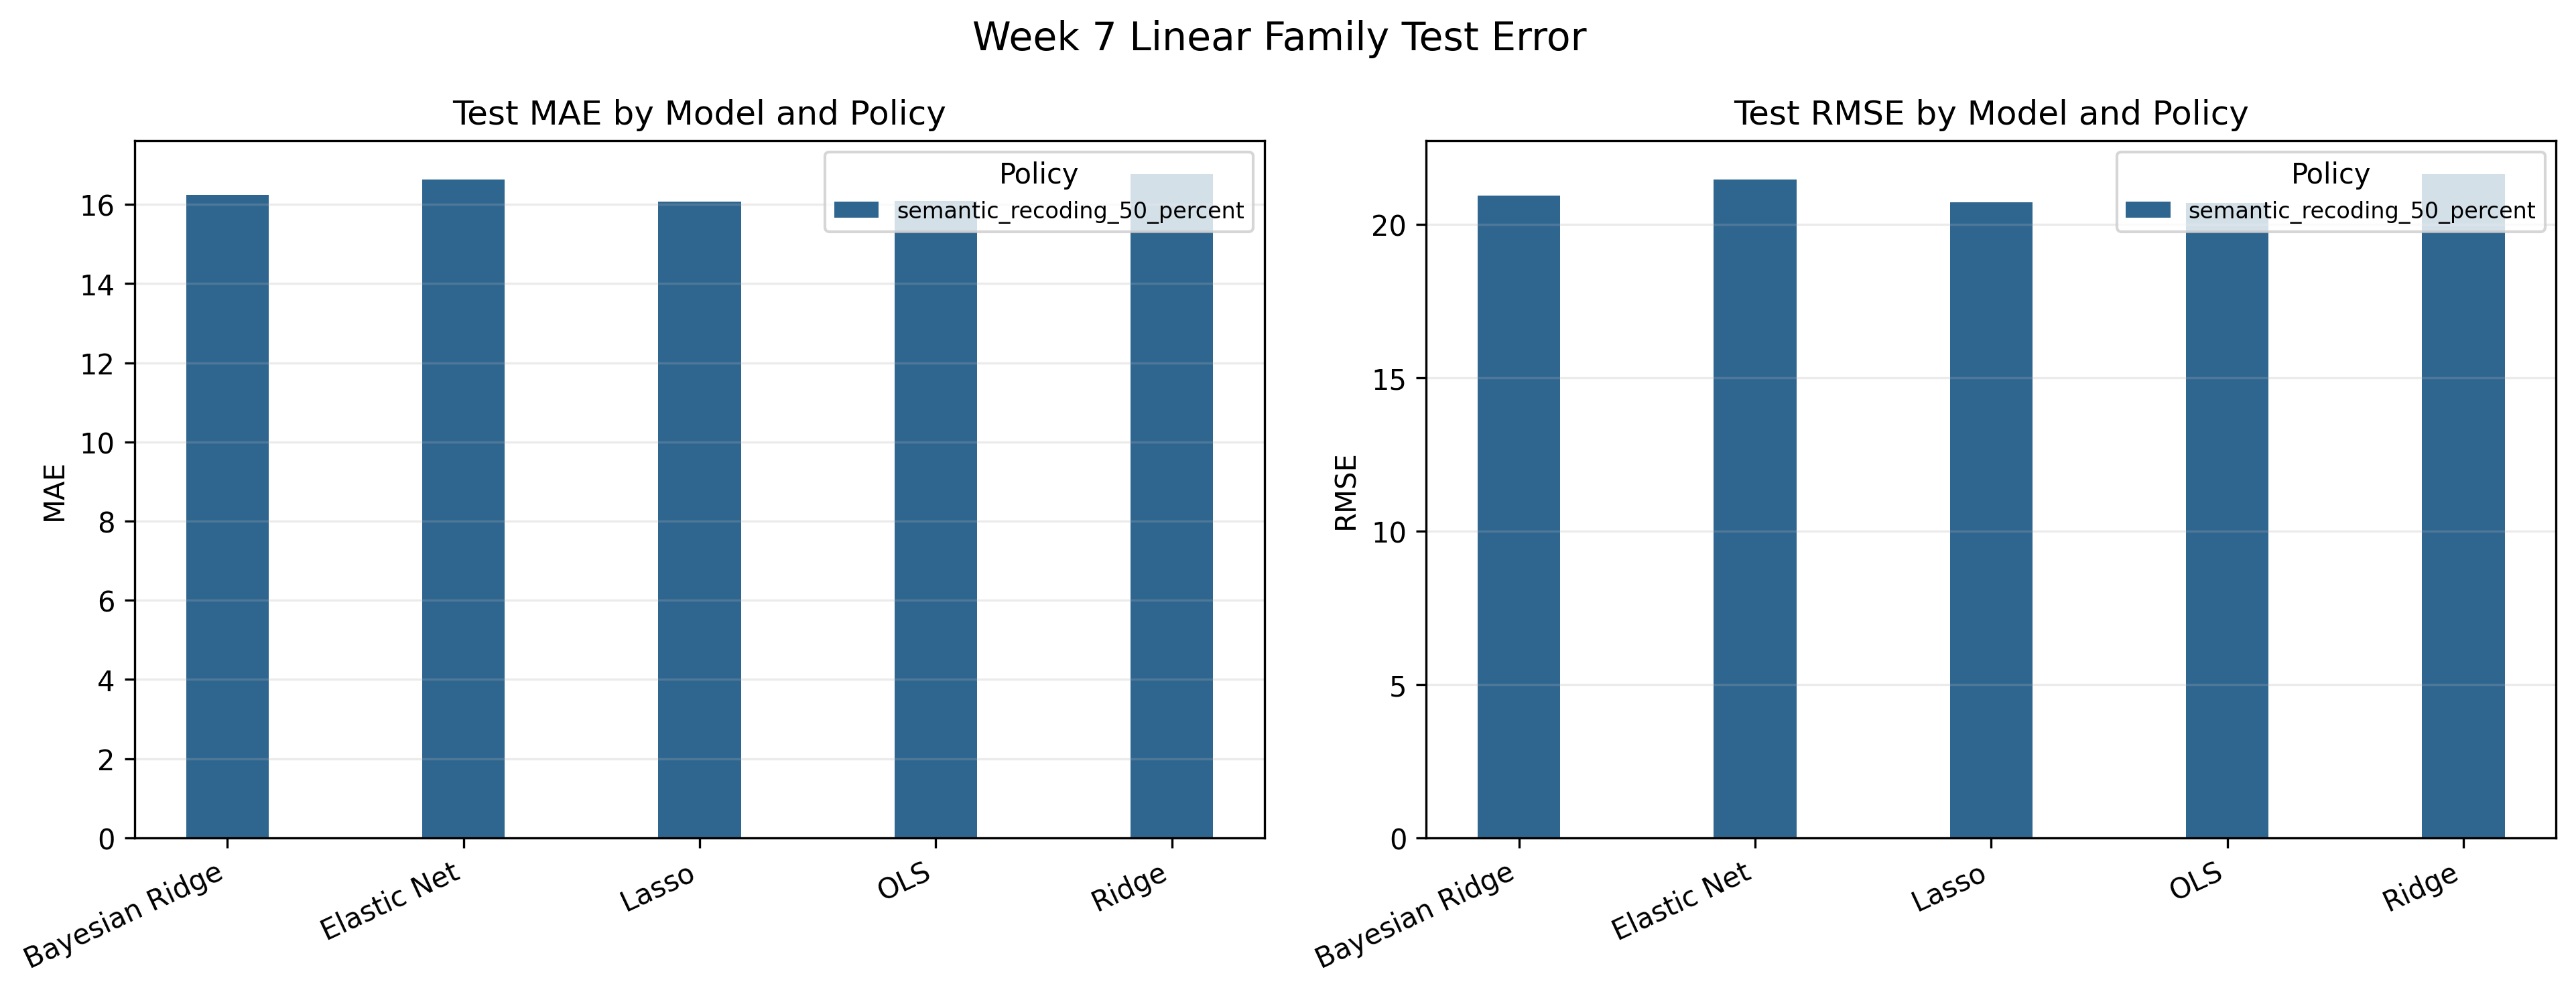

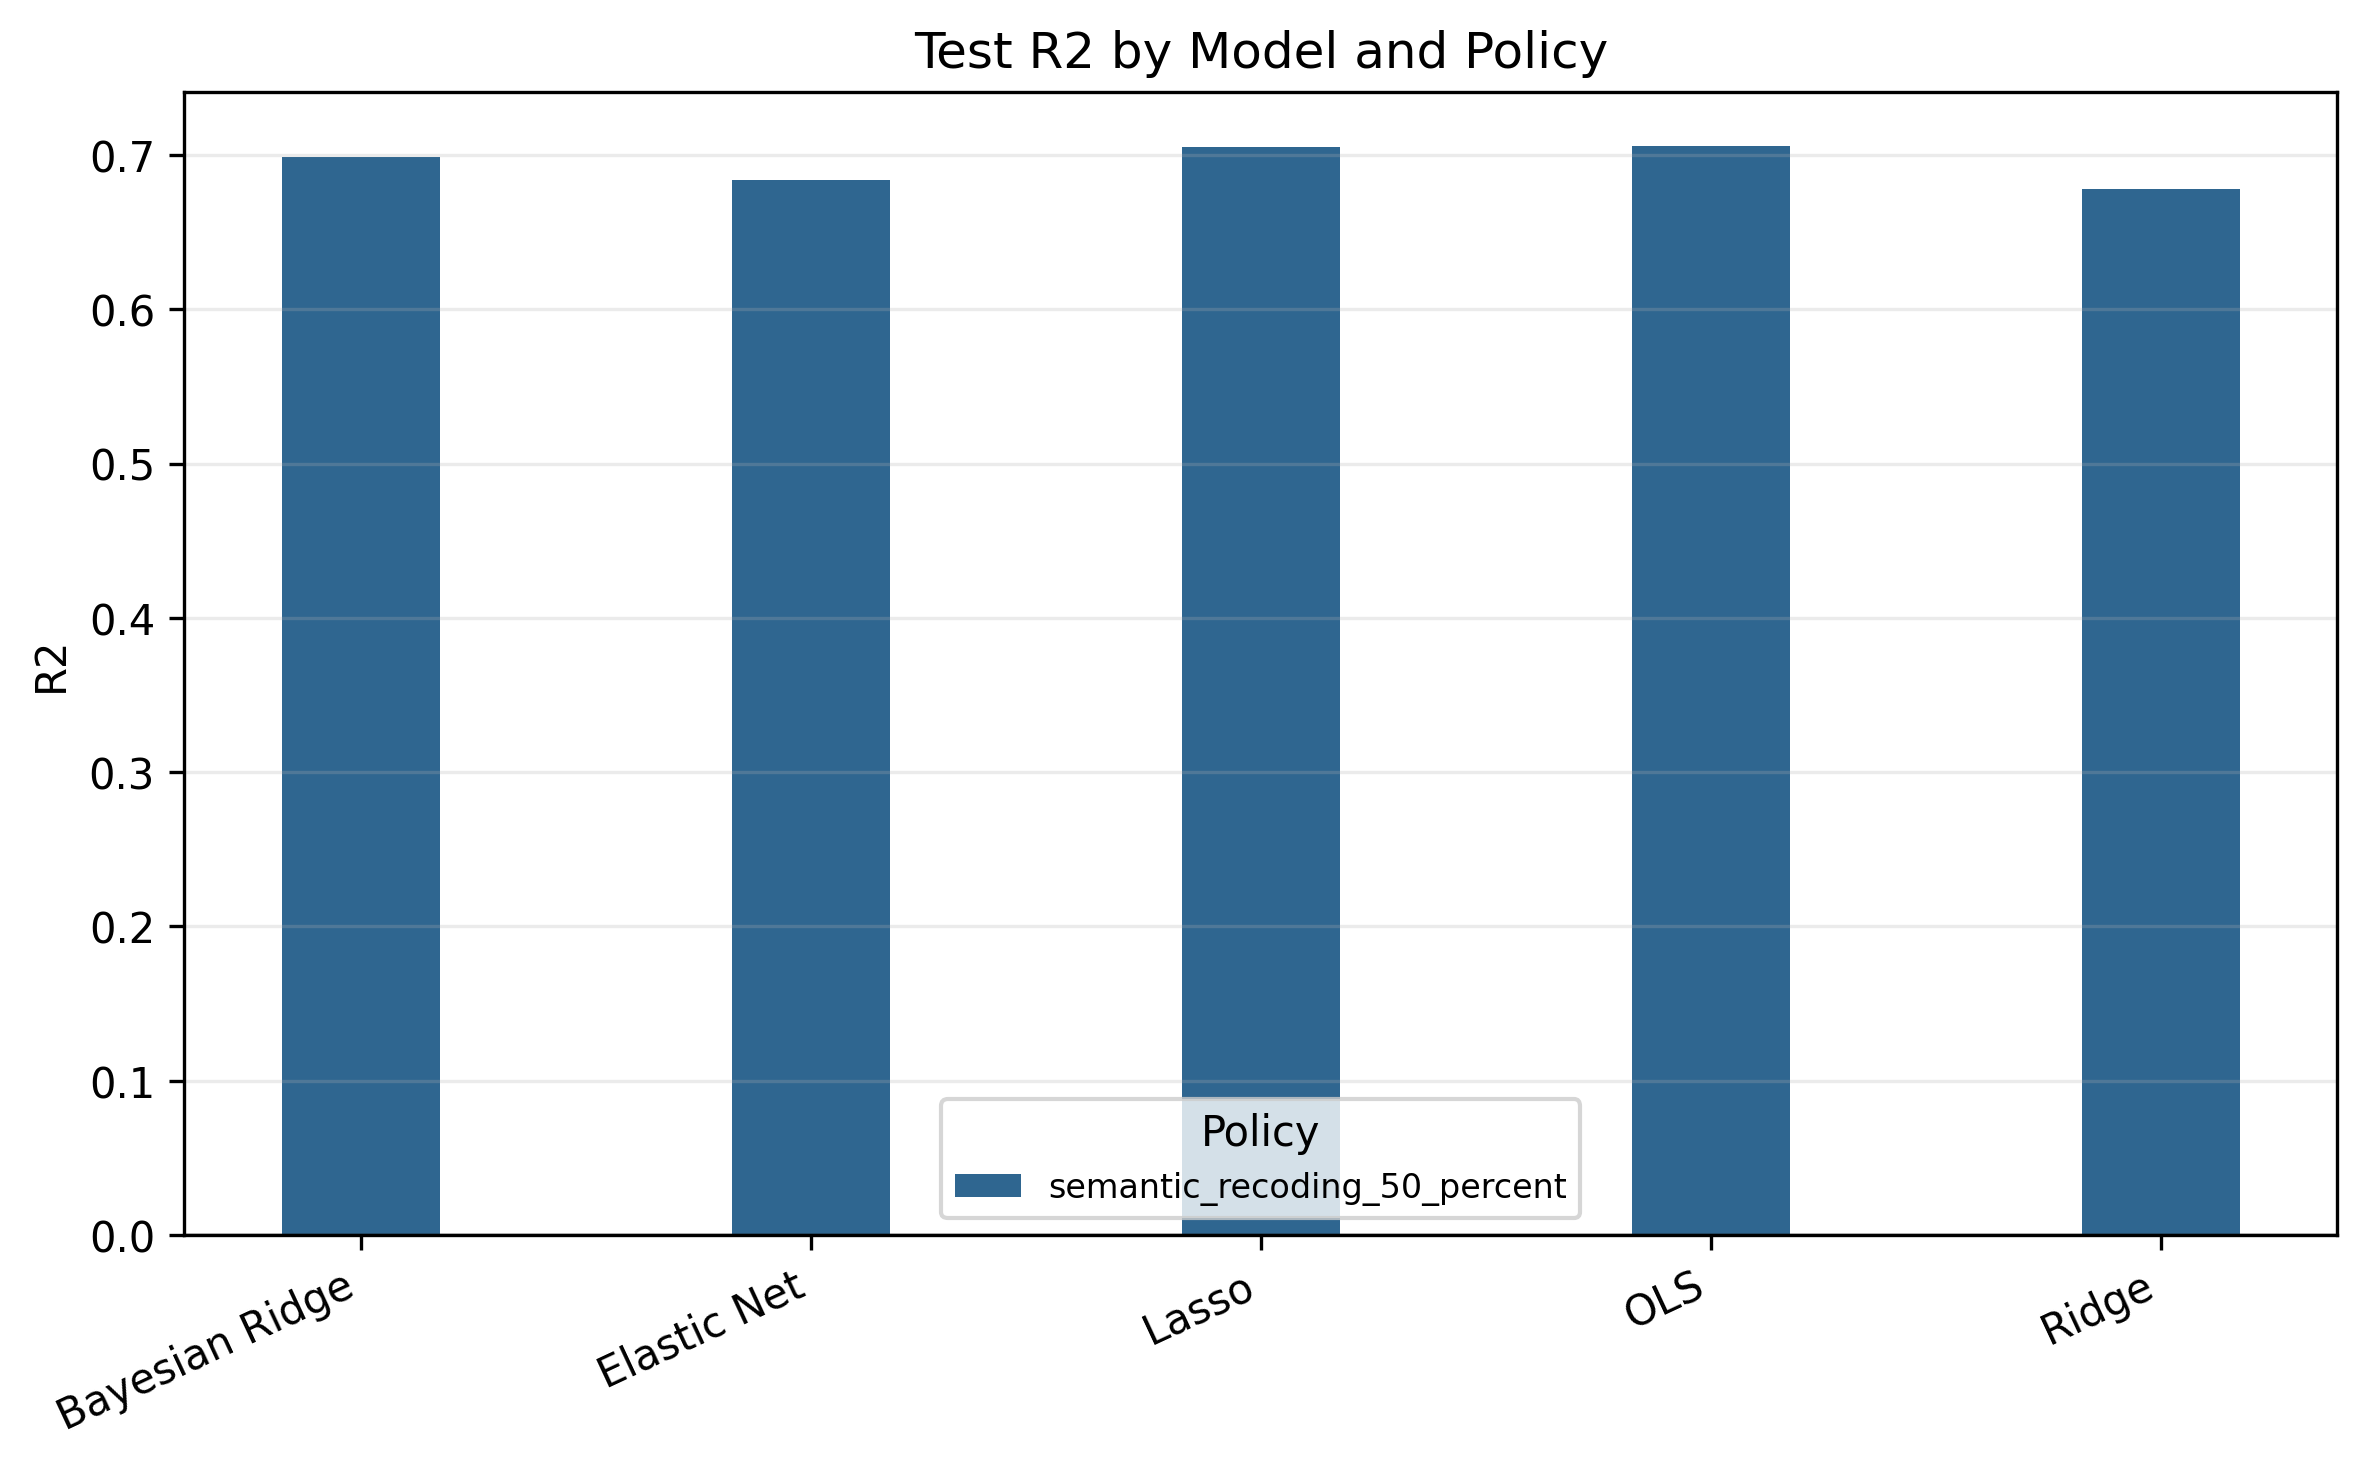

In [4]:
show_figure("week07_metrics_comparison.png", width=1100)
show_figure("week07_r2_comparison.png", width=850)

The models are fairly close to each other, but Lasso and OLS perform best in this fixed-parameter setup. Ridge is more conservative because its L2 penalty shrinks all coefficients, and in this dataset that slightly increases test error. Elastic Net and Bayesian Ridge are also competitive but not the validation-selected baseline.

Because only the 50 percent policy is used this week, the policy legend contains one policy. The comparison is still useful because it shows model differences under the agreed dataset policy.

## 6. Selected Baseline: Prediction Behavior

The next plots focus on the validation-selected Lasso model on the unchanged test set. These plots answer a different question from the metrics table: not only *how large* the error is, but *where* the error appears.

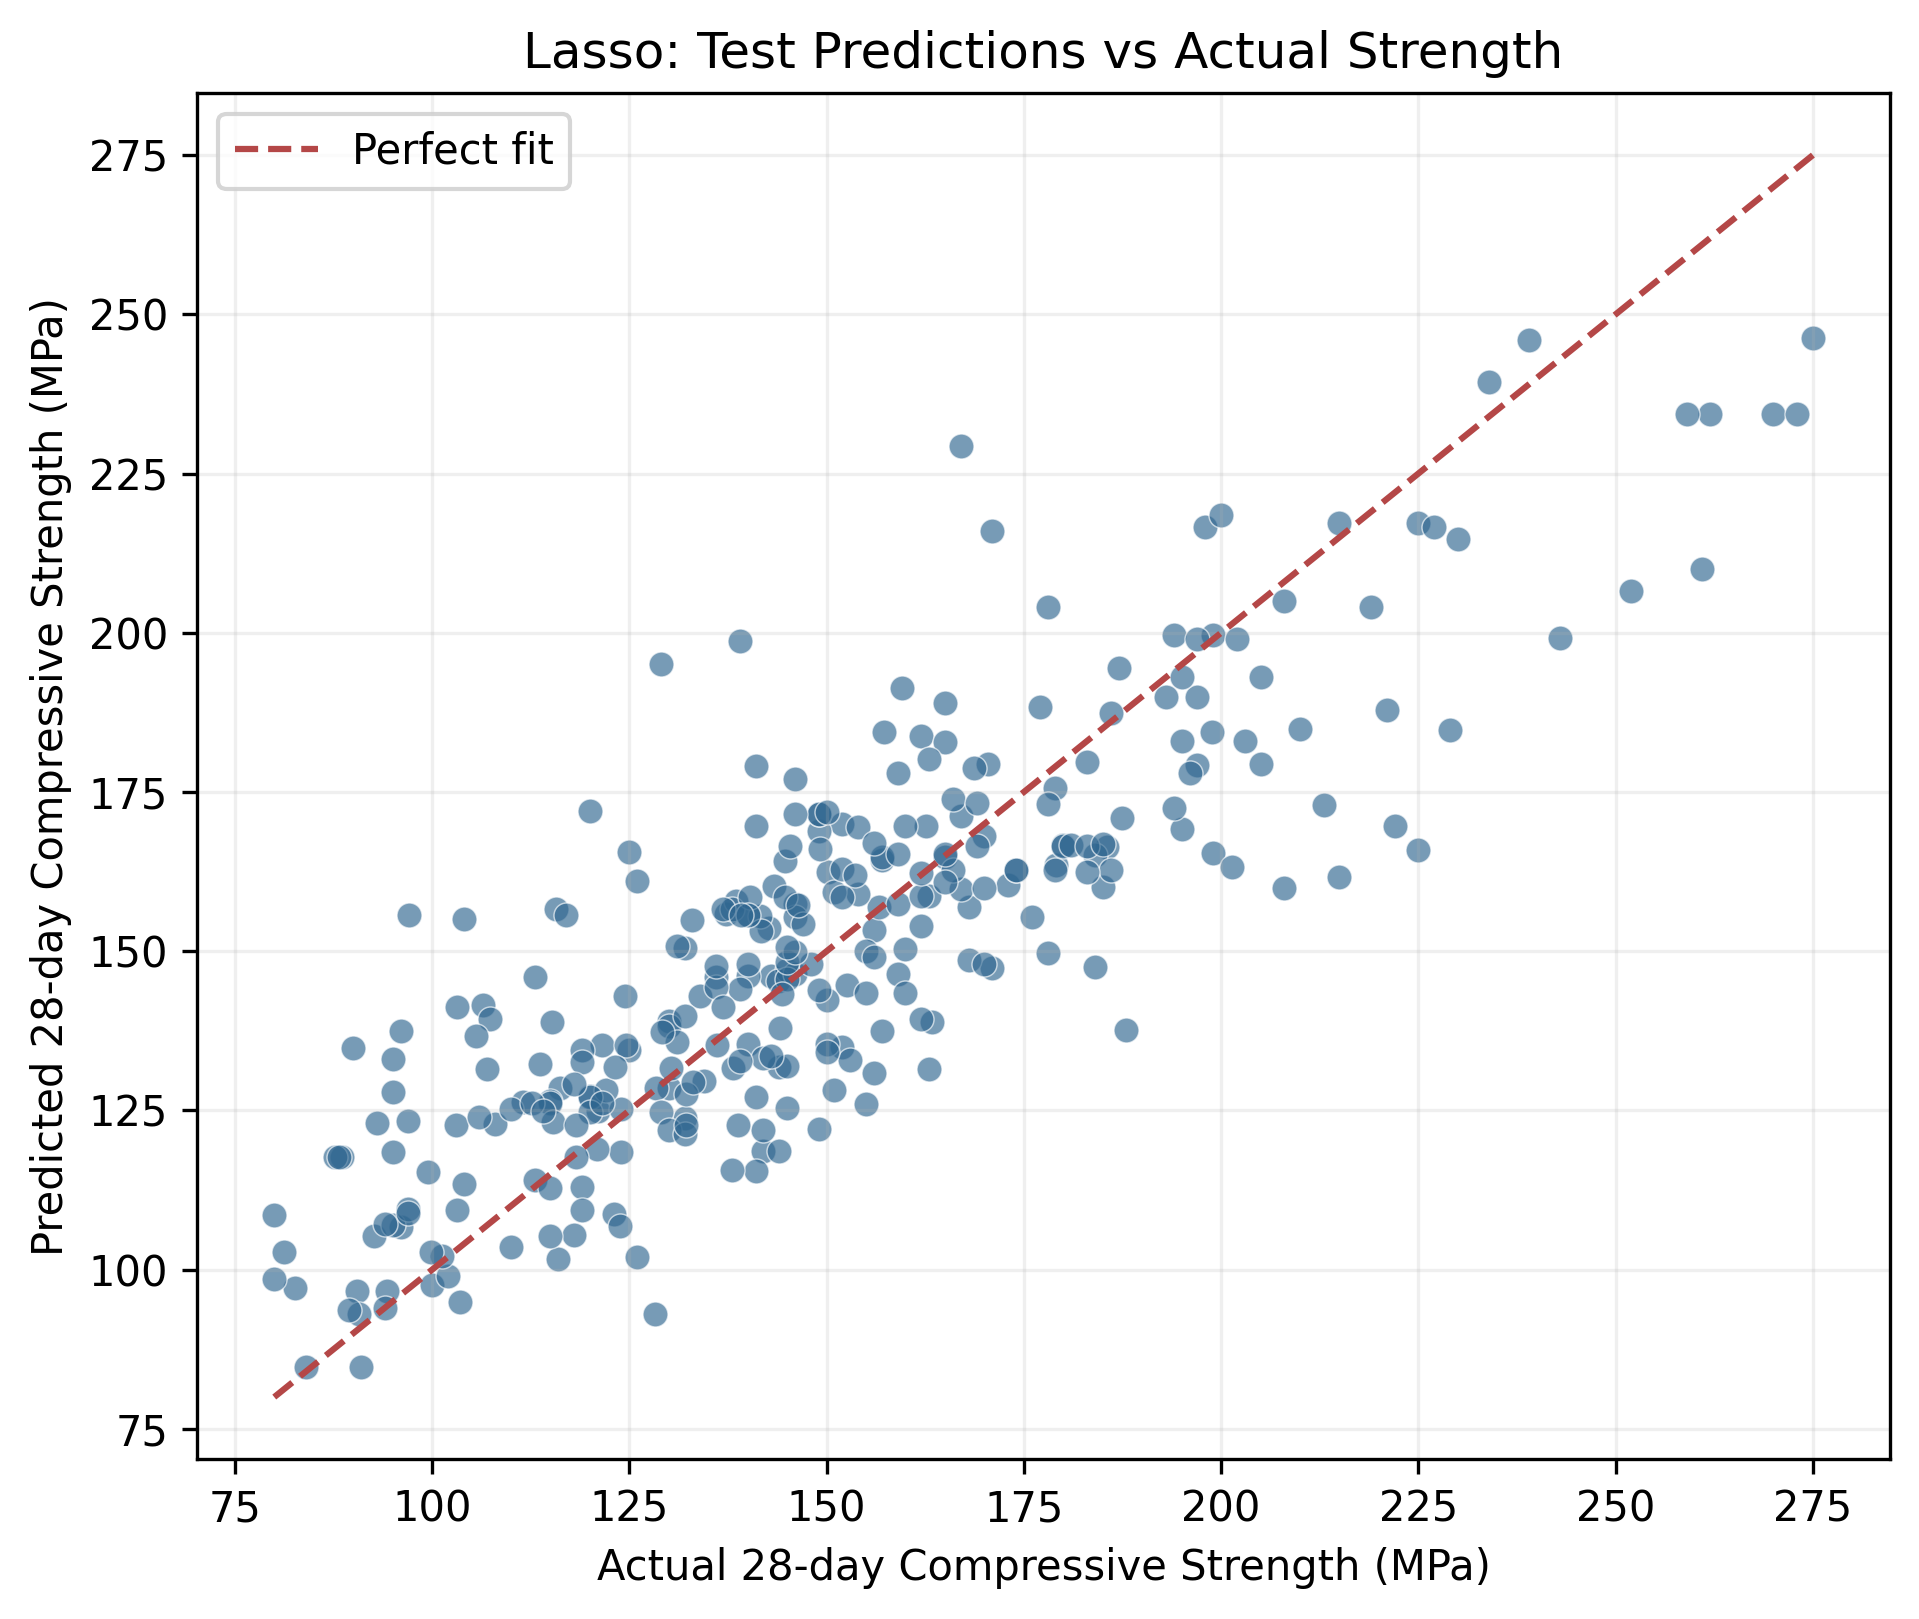

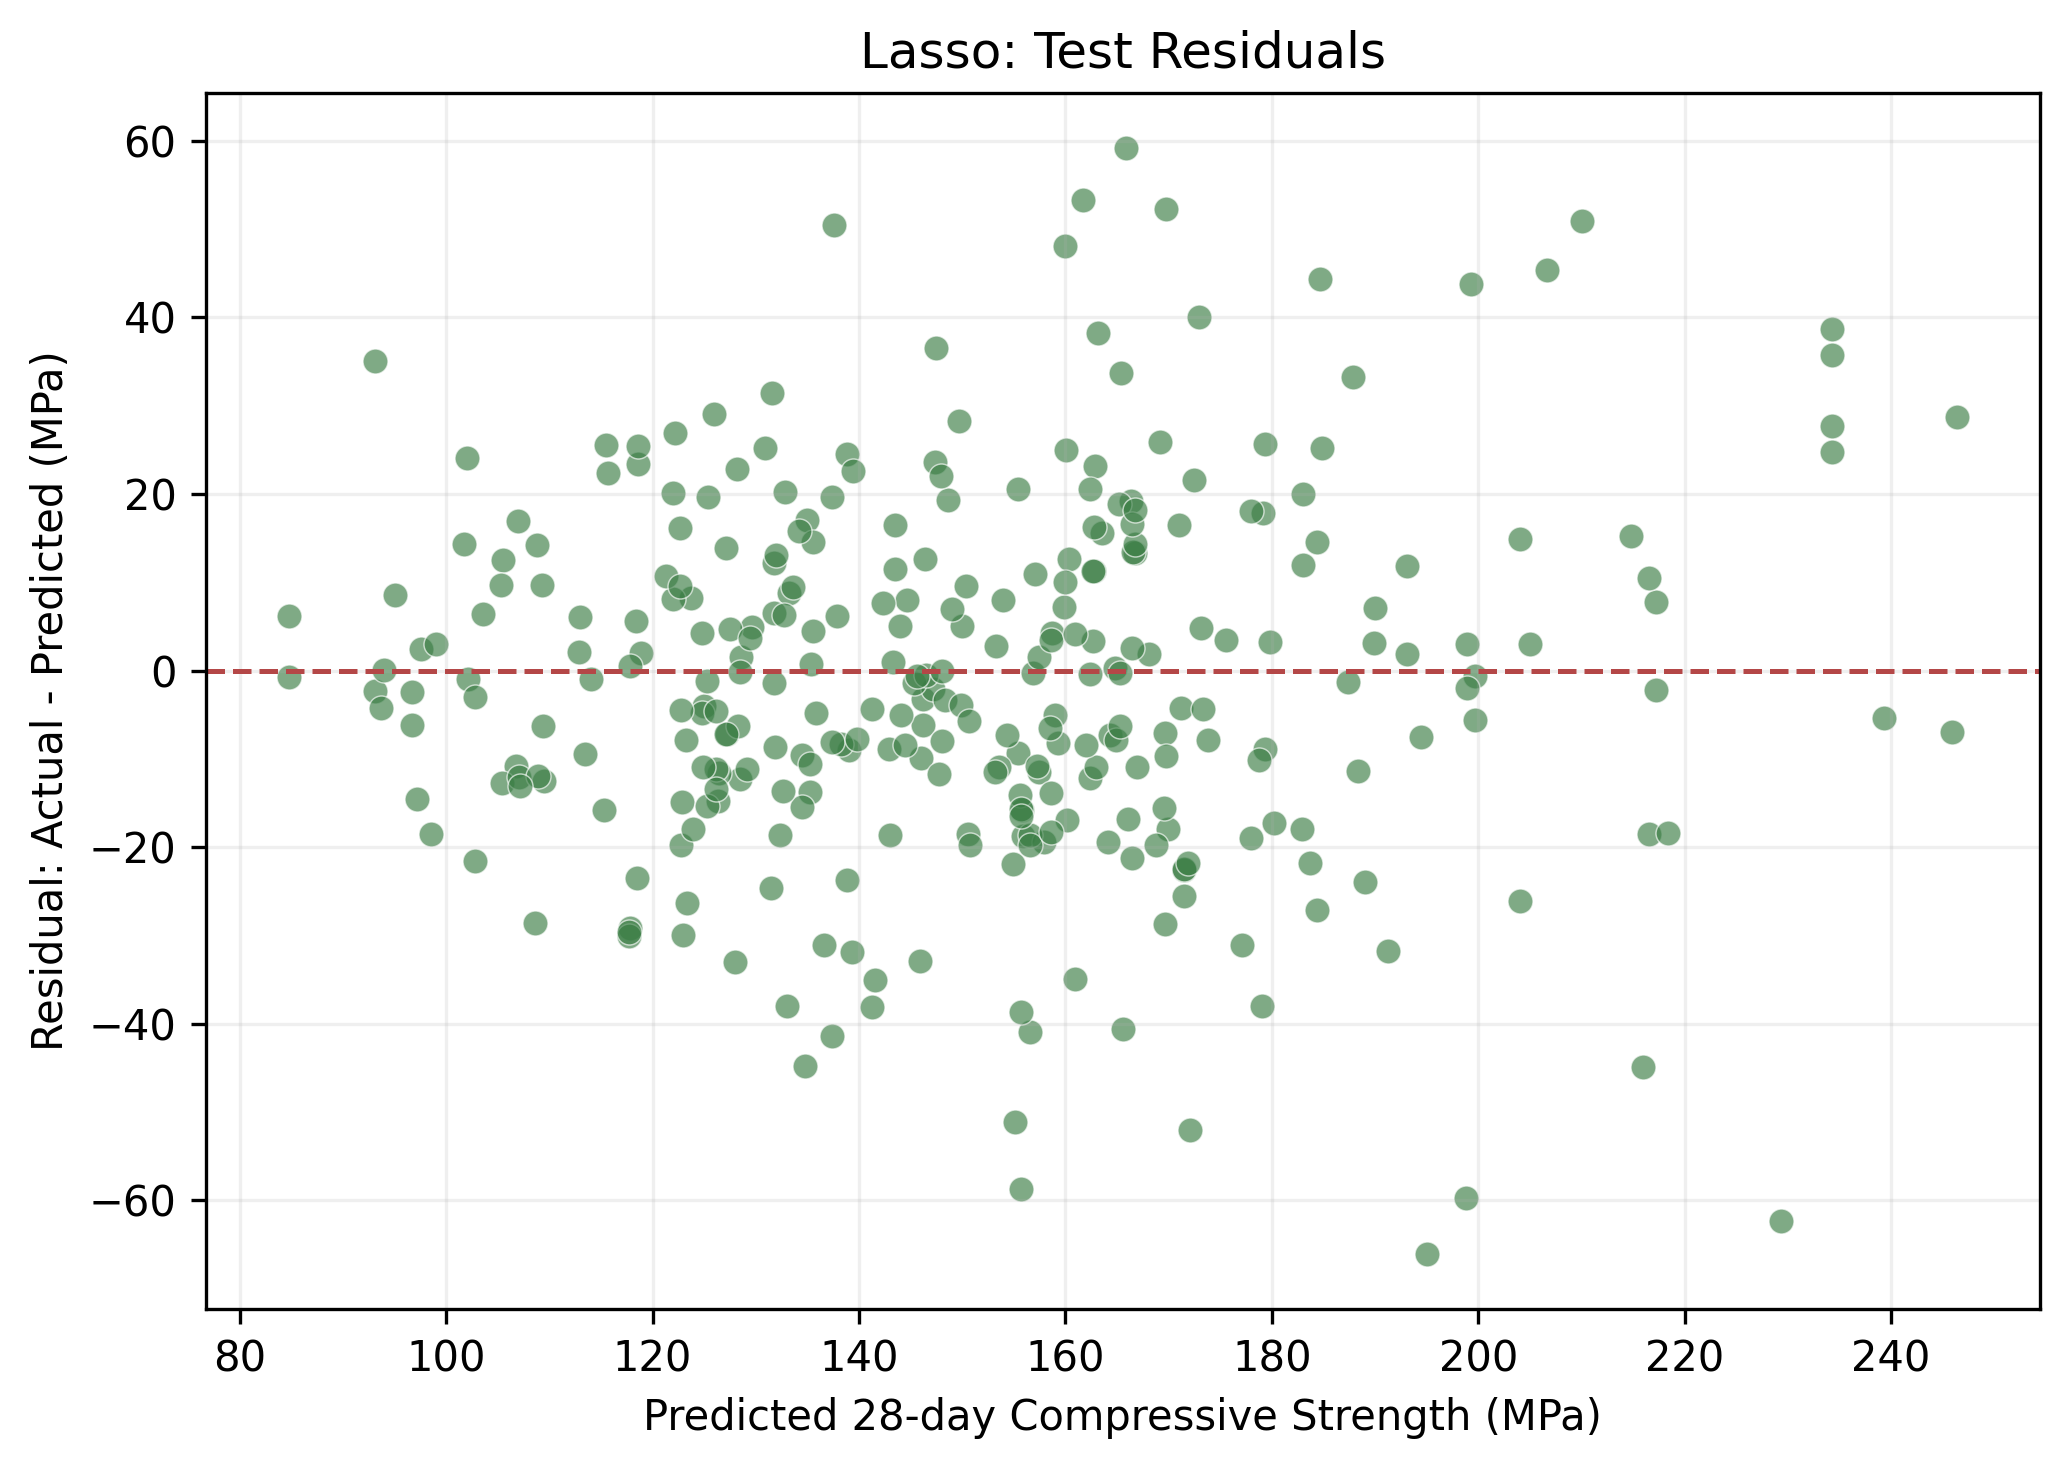

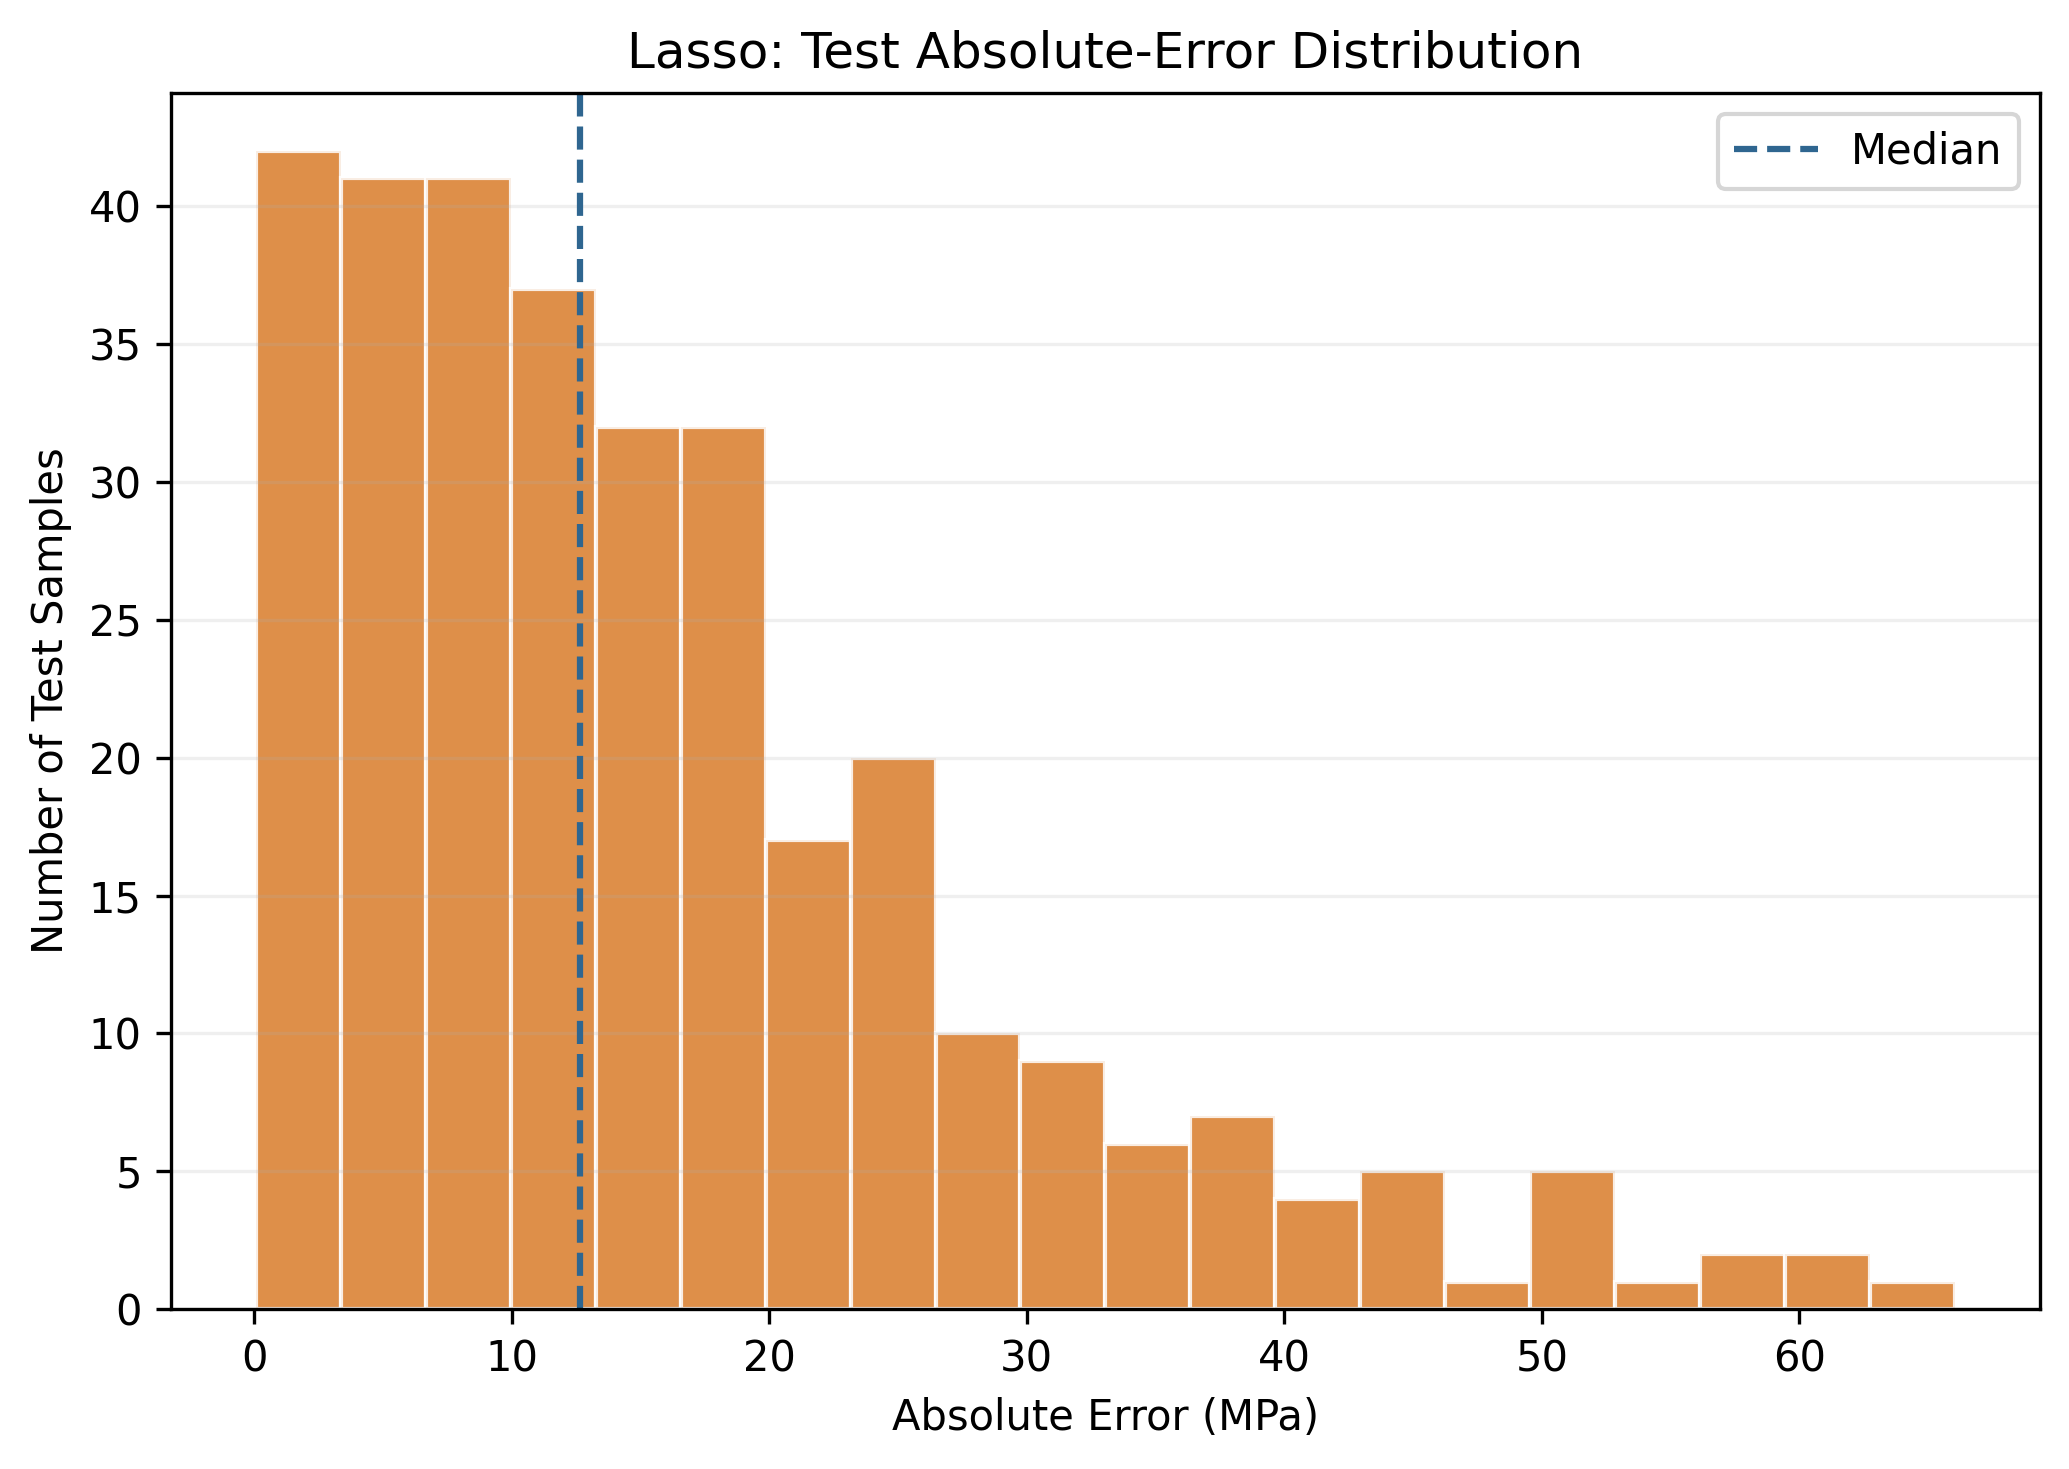

,Actual,Predicted,Residual,AbsoluteError
count,315.000,315.000,315.000,315.000
mean,149.202,150.563,-1.360,16.073
std,38.240,31.303,20.716,13.109
min,80.000,84.777,-66.044,0.058
25%,121.750,127.736,-13.663,6.273
50%,145.000,149.038,-1.947,12.629
75%,168.850,166.753,11.918,21.972
max,275.000,246.343,59.120,66.044


In [5]:
baseline_predictions = load_table("week07_baseline_predictions.csv")
best_name = best_model.loc[0, "best_model"]
best_predictions = baseline_predictions.query("split == 'test' and model == @best_name")

show_figure("week07_selected_baseline_predicted_vs_actual.png", width=750)
show_figure("week07_selected_baseline_residuals.png", width=850)
show_figure("week07_selected_baseline_error_distribution.png", width=850)

display(rounded(best_predictions[["Actual", "Predicted", "Residual", "AbsoluteError"]].describe()))

### Prediction Interpretation

The predicted-vs-actual plot follows the diagonal for many test samples, so the model is learning a useful linear signal. However, the outer strength ranges show the classic regression-to-the-mean pattern: very high strengths tend to be underpredicted, while lower strengths can be overpredicted.

The residual plot shows that the model is not simply making one constant offset error. Instead, residual spread increases in some parts of the prediction range, which suggests that the dataset contains subgroups whose behavior is not fully captured by a single global linear relationship.

The absolute-error distribution shows that many predictions are in a moderate error range, but there are also large-error samples. Those large errors are important for Week 7 interpretation because they may correspond to special curing regimes, unusual binders, special fiber systems, or reporting differences across literature sources.

## 7. VIF Diagnostic

VIF checks how strongly one numeric predictor can be explained by the other numeric predictors. It does **not** use the target, and it is **not** a model score.

VIF is mainly useful for interpreting OLS coefficient stability. If VIF is high, a model can still predict reasonably, but individual coefficients become harder to trust because correlated ingredients can trade importance with each other.

,policy,max_vif,median_vif,number_features_vif_above_5,number_features_vif_above_10,number_inf_vif
0,semantic_recoding_50_percent,3.539,1.431,0,0,0


,policy,feature,VIF,R2_against_other_features,interpretation
0,semantic_recoding_50_percent,cement,3.539,0.717,acceptable
1,semantic_recoding_50_percent,sand,3.139,0.681,acceptable
2,semantic_recoding_50_percent,fly_ash,2.913,0.657,acceptable
3,semantic_recoding_50_percent,ggbfs,2.281,0.562,acceptable
4,semantic_recoding_50_percent,water,2.061,0.515,acceptable
5,semantic_recoding_50_percent,silica_fume,1.960,0.490,acceptable
6,semantic_recoding_50_percent,quartz_powder,1.850,0.460,acceptable
7,semantic_recoding_50_percent,glass_powder,1.777,0.437,acceptable
8,semantic_recoding_50_percent,filler,1.692,0.409,acceptable
9,semantic_recoding_50_percent,fiber1_diameter,1.568,0.362,acceptable


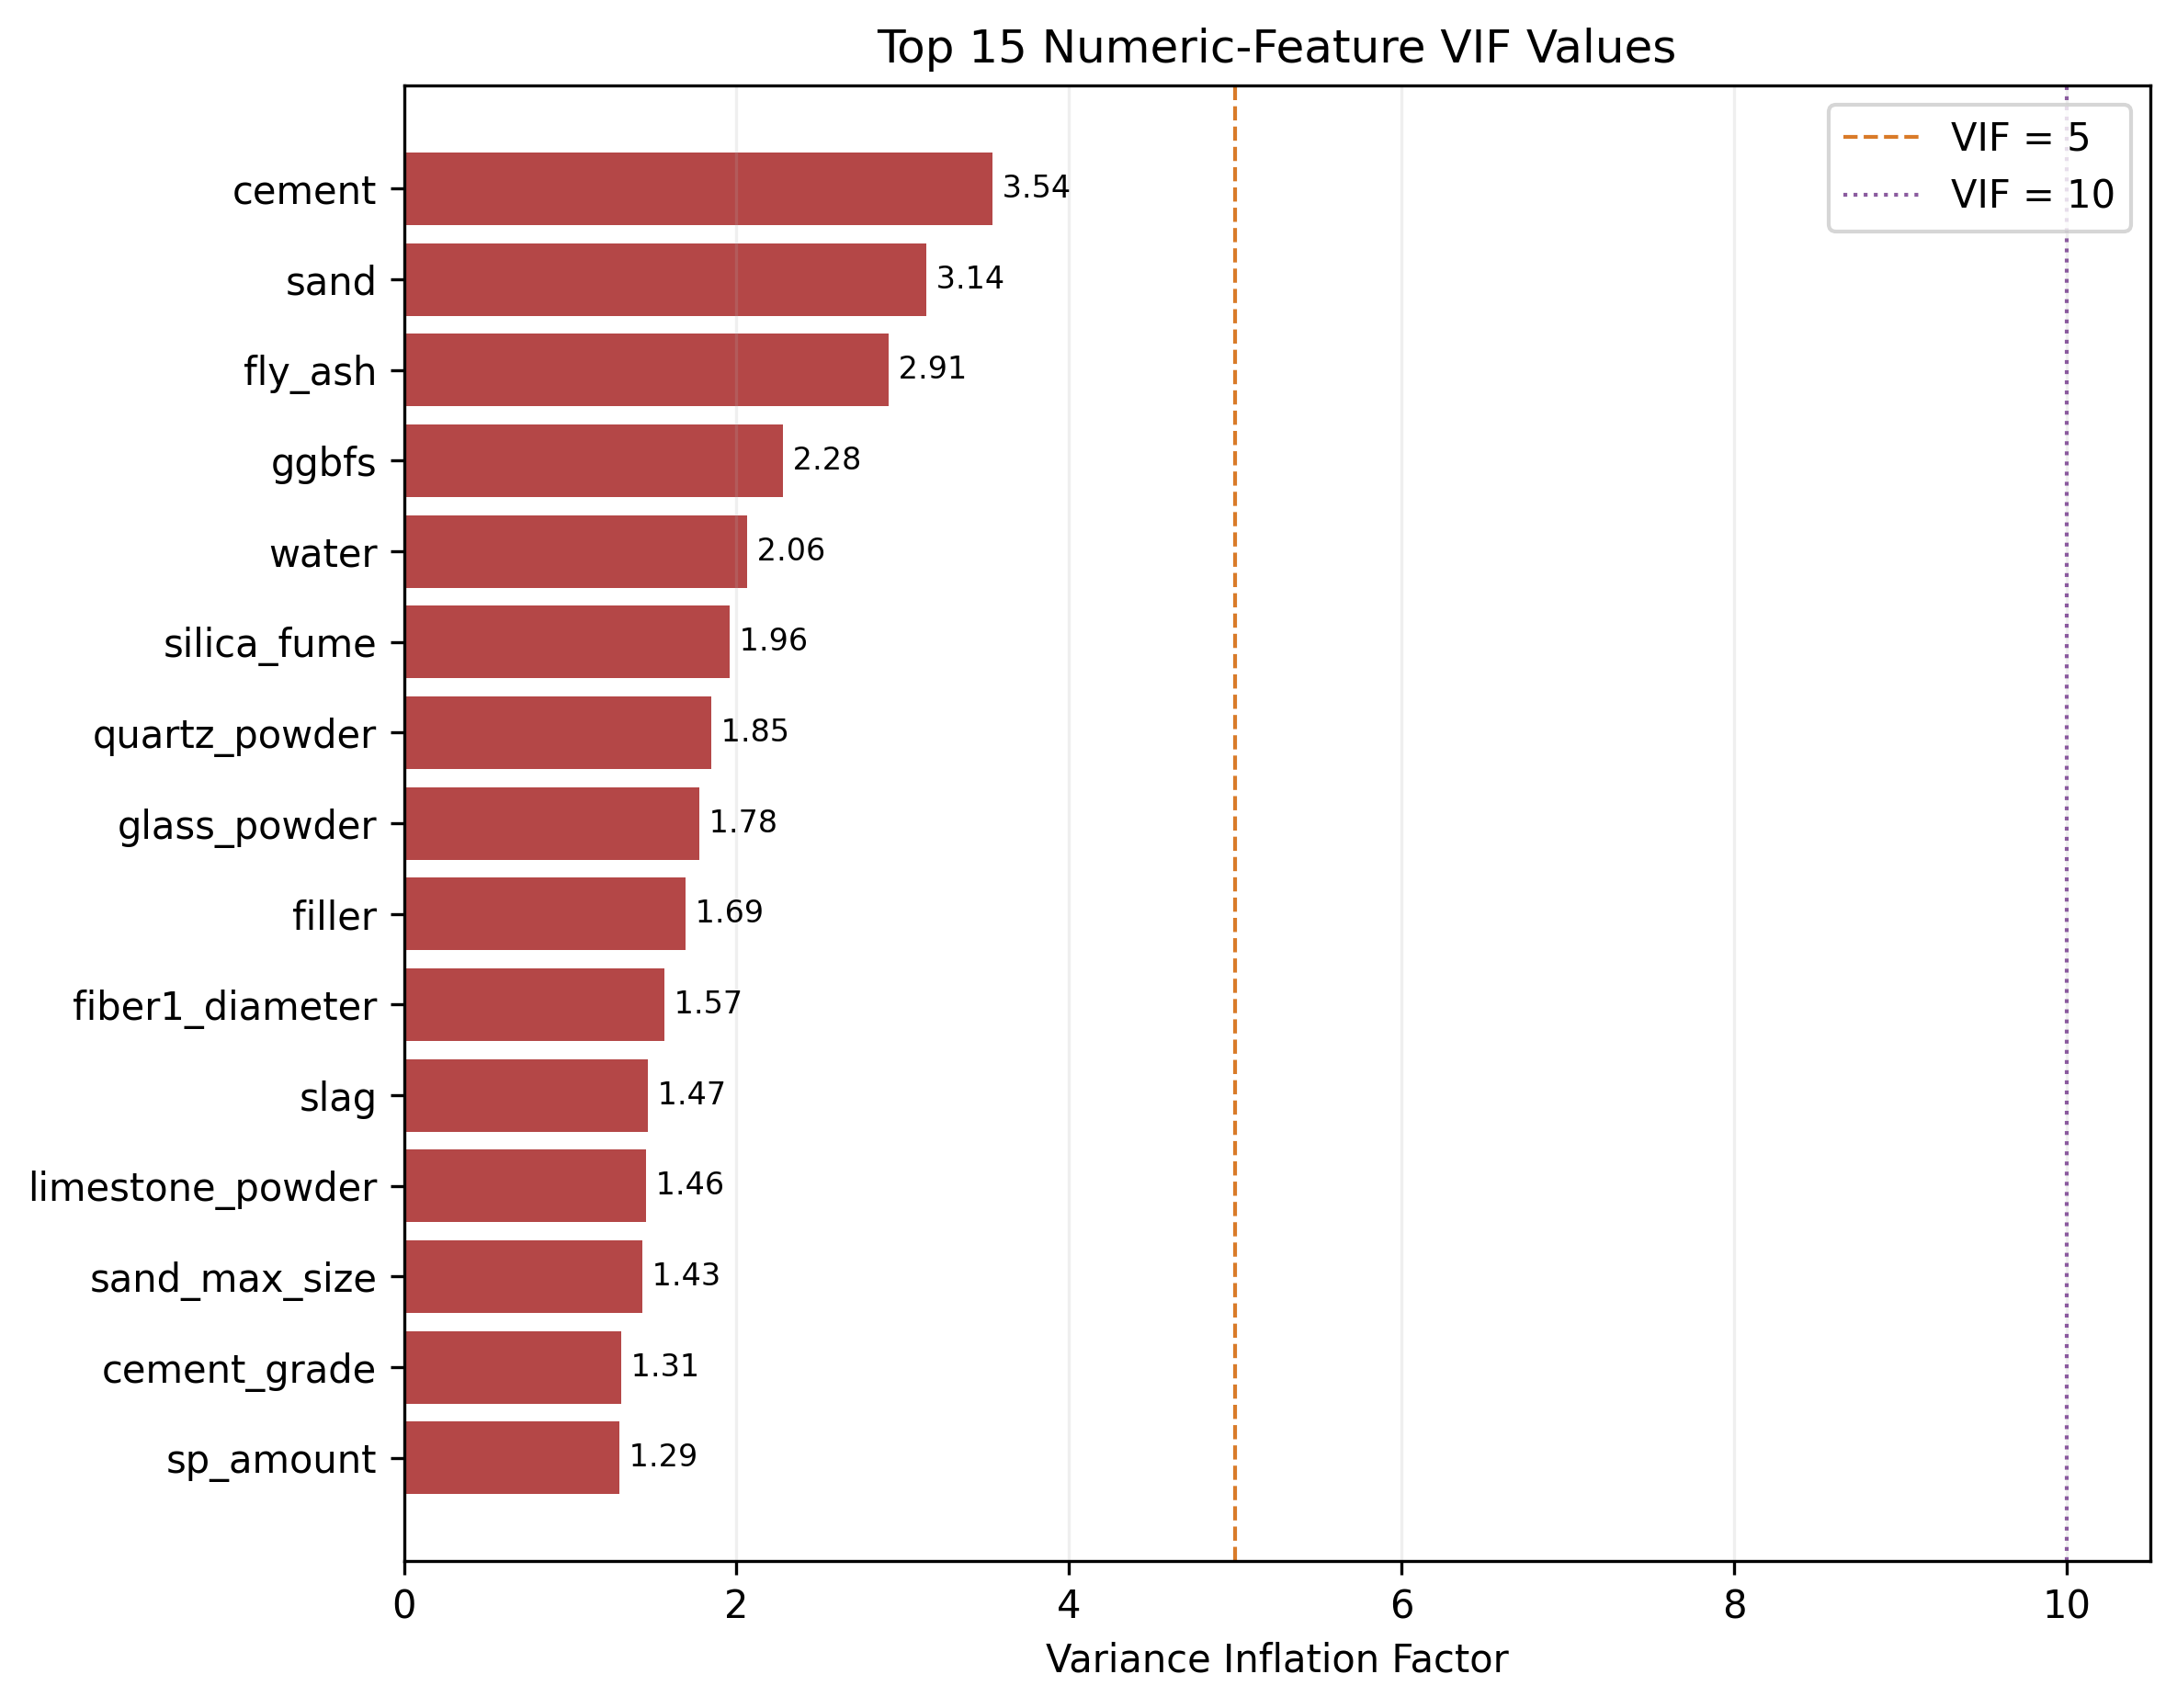

In [6]:
vif_table = load_table("week07_numeric_vif.csv")
vif_summary = load_table("week07_numeric_vif_summary.csv")

display(rounded(vif_summary))
display(rounded(vif_table.head(15)))
show_figure("week07_top_vif.png", width=900)

The maximum VIF is about 3.54 and the median VIF is about 1.43. There are no numeric features above 5, no features above 10, and no infinite VIF values.

For this current 50 percent dataset, numeric ingredient multicollinearity is not severe. That supports using coefficient plots as a rough diagnostic, but coefficients still need care because the model includes one-hot encoded categories and missing indicators in addition to scaled numeric ingredients.

## 8. Error by Strength Range

Strength-range analysis checks whether the baseline performs similarly across low, medium, and high UHPC strengths. This matters because a model that looks good on average may still fail on the high-strength region that is often most important in UHPC applications.

,strength_bin,n_rows,MAE,RMSE,Bias,MedianAE,ActualMean,PredictedMean
0,>180,58,22.198,27.220,19.833,18.681,210.126,190.292
1,<=120,75,17.424,22.211,-15.250,13.110,103.966,119.216
2,120-150,105,13.475,17.550,-4.745,10.742,137.465,142.210
3,150-180,77,13.686,17.294,0.820,11.254,163.379,162.560


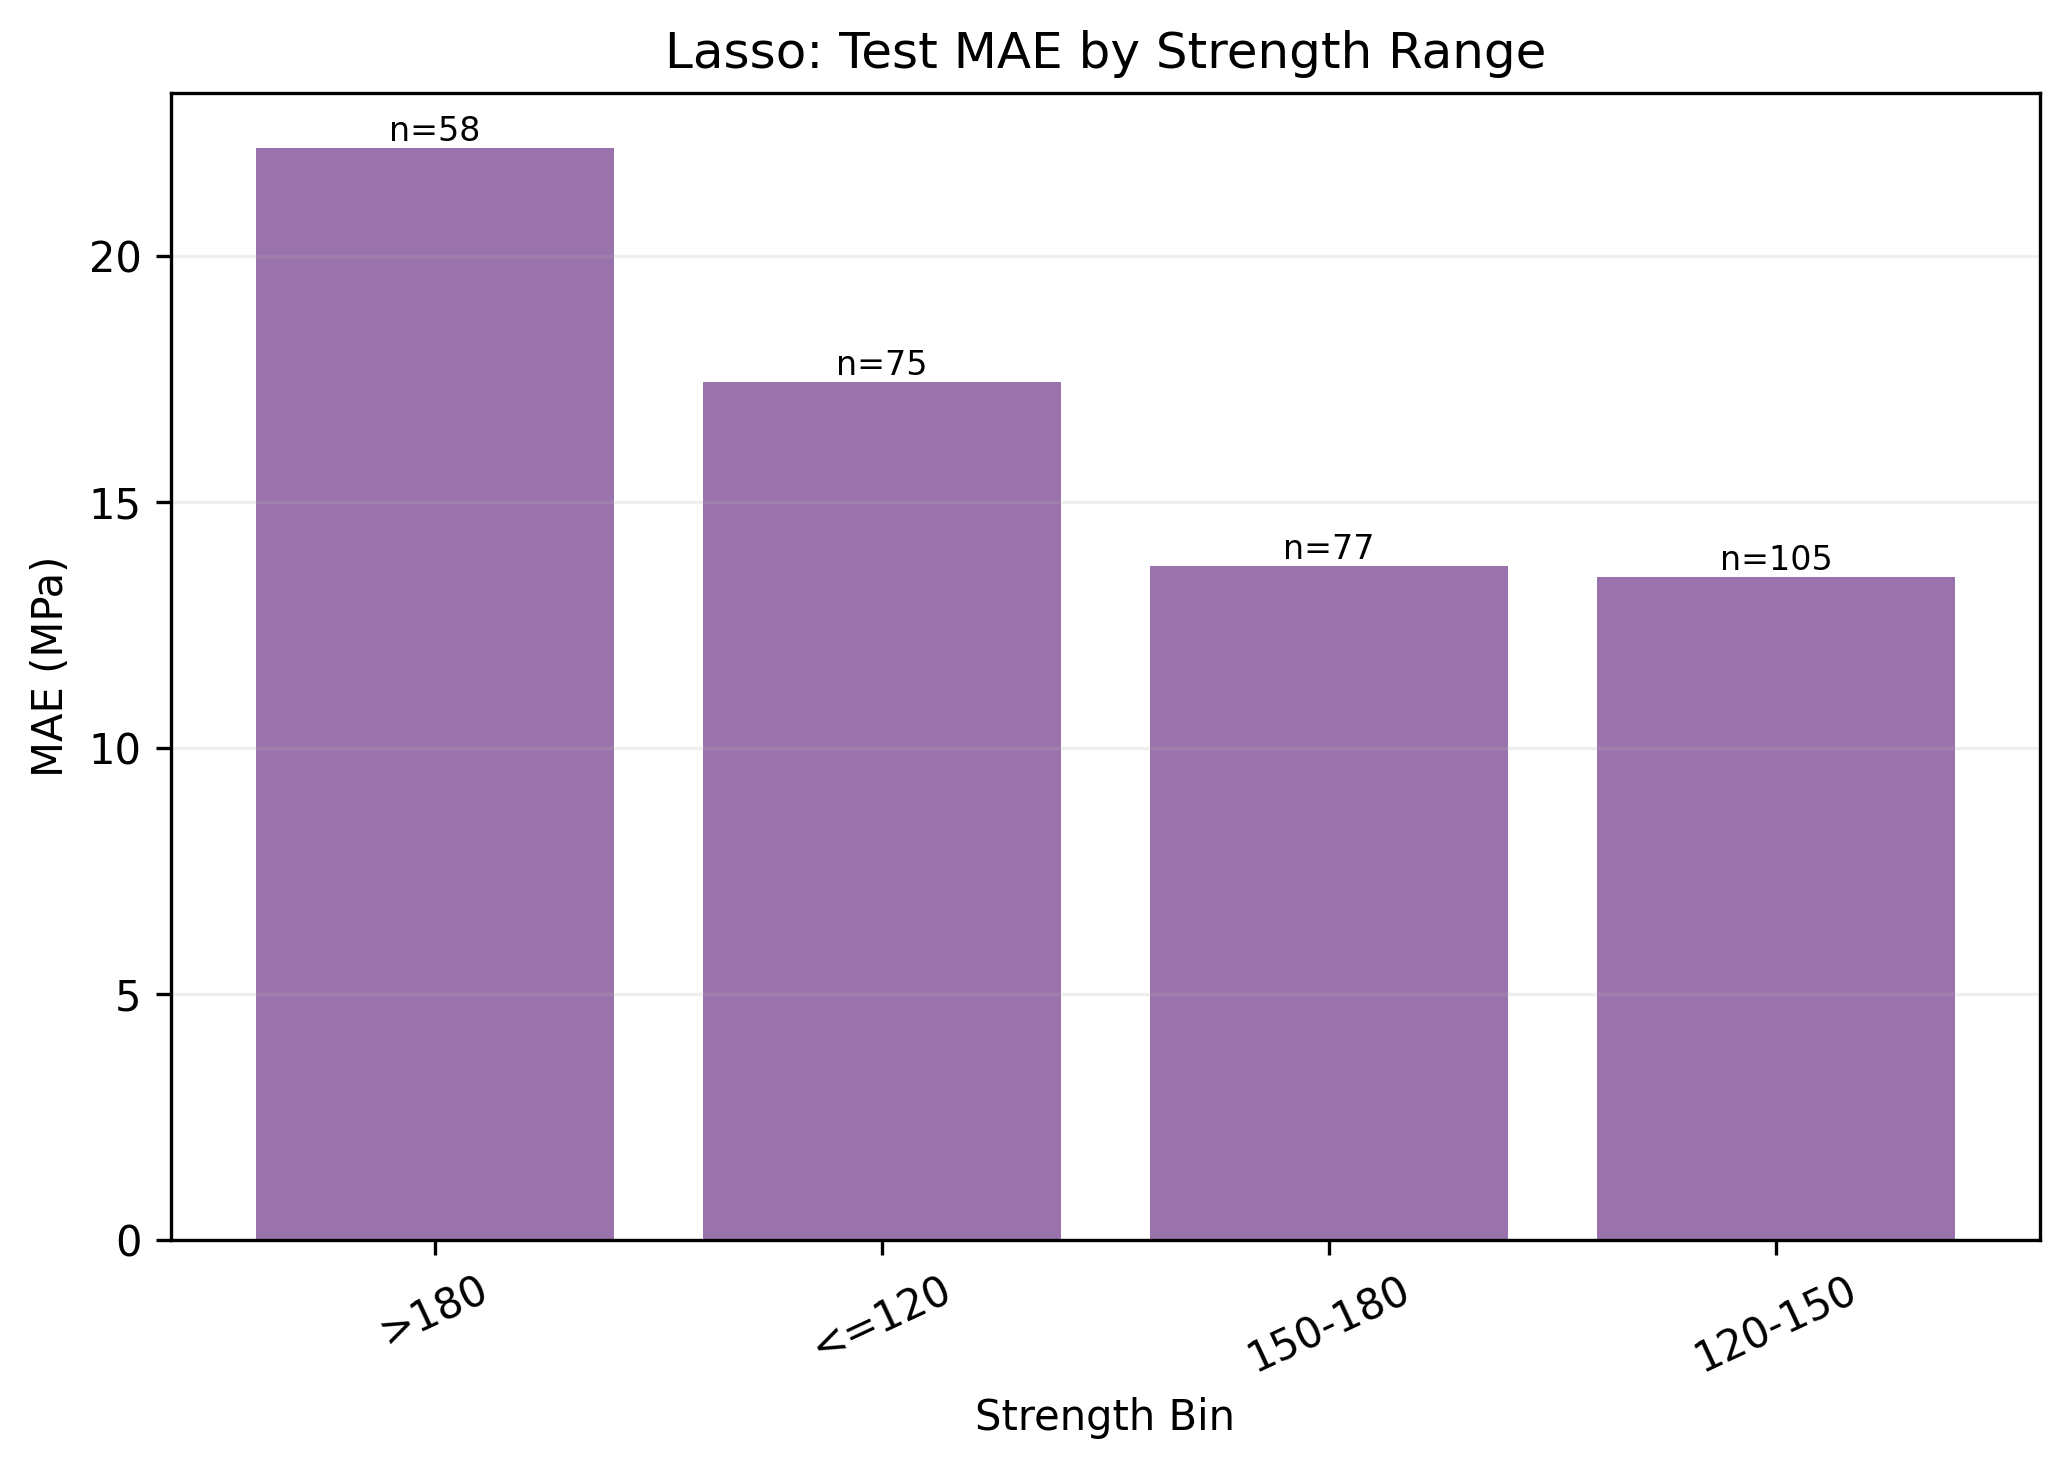

In [7]:
strength_error = load_table("week07_best_model_error_by_strength.csv")
display(rounded(strength_error))
show_figure("week07_error_by_strength_bin.png", width=850)

The highest-strength bin (`>180 MPa`) has the largest error. Its bias is positive for residuals (`Actual - Predicted`), which means the model tends to underpredict very high-strength mixes. The lowest bin (`<=120 MPa`) has negative bias, which means the model tends to overpredict lower-strength mixes.

This is one of the clearest findings from Week 7: the global linear model captures the center of the data better than the extremes. More flexible nonlinear models, better domain features, or subgroup-aware modeling may be needed to improve these boundary regions.

## 9. Curing Regime Error Analysis

Curing affects hydration, pozzolanic reaction, microstructure formation, and early/late strength development. Therefore it is not only a metadata field; it can change the strength mechanism itself.

This experiment does not retrain separate curing models. It analyzes the selected baseline's test errors by broad curing group.

,curing_group,n_rows,MAE,RMSE,Bias,MedianAE,ActualMean,PredictedMean
0,autoclave,13,31.554,38.101,-11.305,35.695,199.154,210.459
1,water,19,18.621,23.452,-0.936,16.505,138.168,139.104
2,steam,62,18.596,23.427,-0.158,16.097,166.131,166.289
3,heat,40,16.833,21.952,-0.770,13.983,174.415,175.185
4,standard_or_normal,179,13.775,17.154,-1.277,11.254,135.938,137.215
5,other,2,3.500,4.434,2.723,3.500,87.500,84.777


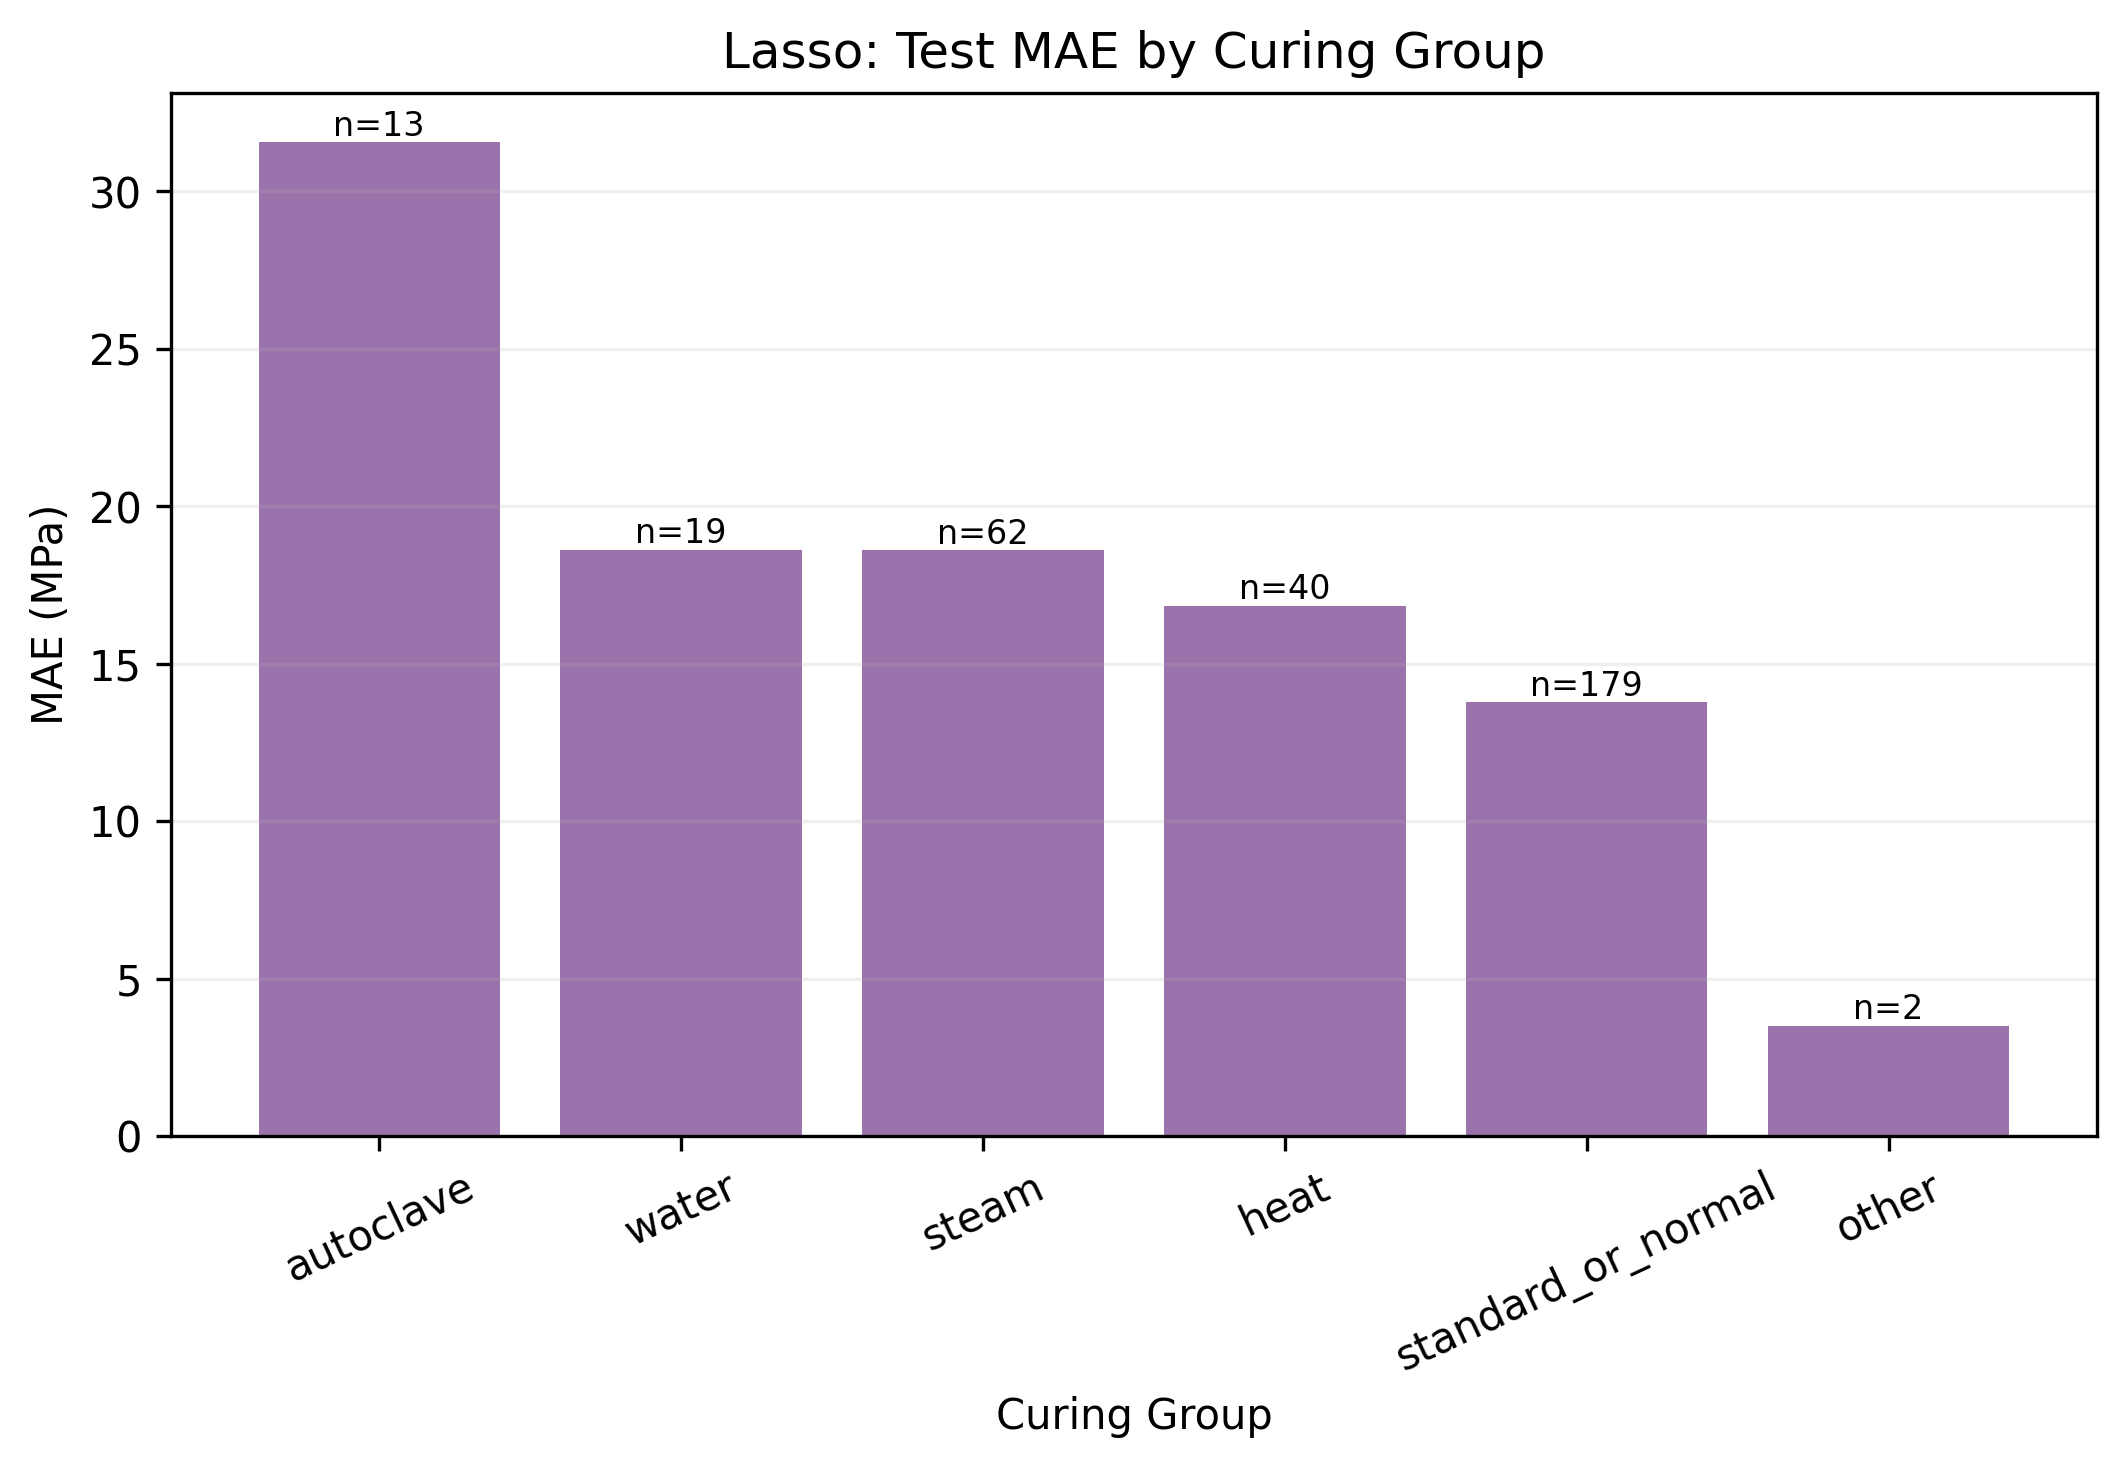

In [8]:
curing_error = load_table("week07_best_model_error_by_curing.csv")
display(rounded(curing_error))
show_figure("week07_error_by_curing_group.png", width=900)

Autoclave curing has the largest error, but it also has only 13 test samples. Water, steam, and heat curing also have higher error than the standard/normal group. The `other` group has very low error, but there are only 2 samples, so that should not be interpreted as a reliable trend.

The engineering interpretation is that special curing regimes may not transfer cleanly through one global linear model. It may be useful to add richer curing features, interactions between curing and binder composition, or group-specific diagnostics once the final dataset is fixed.

## 10. Fiber Group Error Analysis

Fibers are often more directly connected to tensile and flexural behavior than compressive strength. However, fiber presence can still identify a UHPC mix-design class, and the amount/type of fiber may indirectly correlate with strength level, binder system, or curing choice.

,fiber_group,n_rows,MAE,RMSE,Bias,MedianAE,ActualMean,PredictedMean
0,no_fiber_reported,93,16.428,21.672,-5.097,11.890,130.954,136.051
1,fiber_used,222,15.924,20.319,0.205,13.196,156.847,156.642


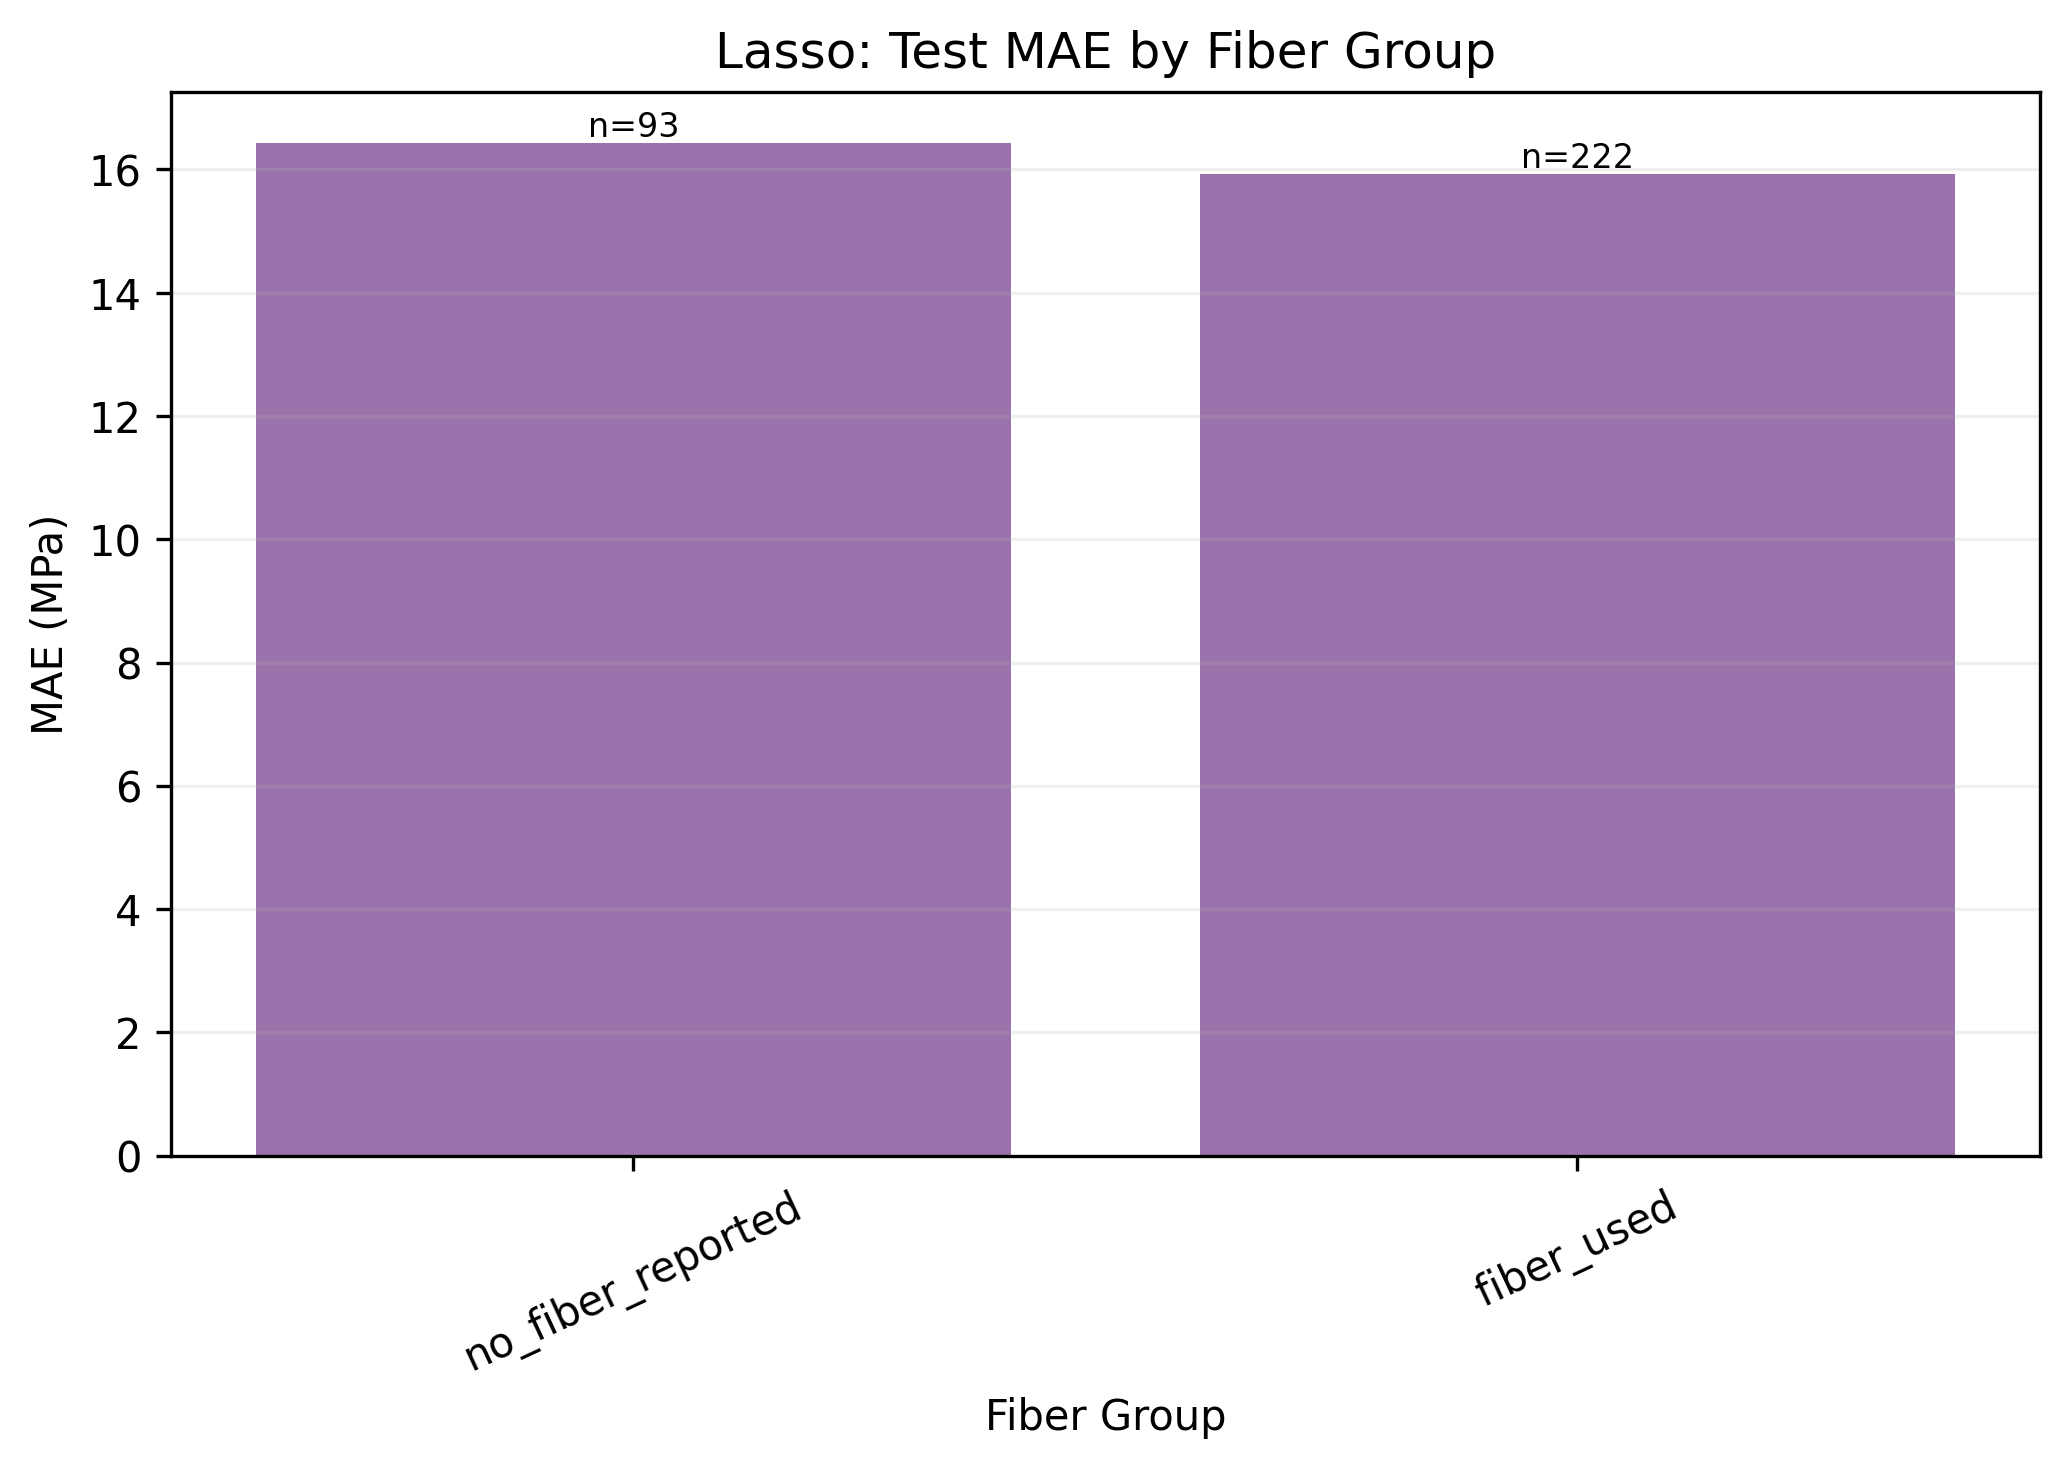

In [9]:
fiber_error = load_table("week07_best_model_error_by_fiber.csv")
display(rounded(fiber_error))
show_figure("week07_error_by_fiber_group.png", width=850)

The no-fiber group has slightly higher RMSE and a more negative residual bias, meaning the model tends to overpredict no-fiber mixes. The fiber-used group is larger and has a lower RMSE. This does not prove fibers directly increase compressive strength; it suggests that fiber information helps represent the broader mix-design context in this dataset.

## 11. Experiment: Fiber Feature Ablation

The fiber ablation experiment trains each fixed model twice on the same train/validation/test rows:

- once with all features,
- once after removing fiber and synergetic-fiber features.

This is a targeted experiment because it asks whether fiber features are useful to the Linear Family models under the current dataset.

,model,delta_MAE,delta_RMSE,delta_R2
3,OLS,2.997,3.313,-0.102
2,Lasso,2.942,3.305,-0.101
0,Bayesian Ridge,2.874,3.287,-0.102
1,Elastic Net,2.828,3.270,-0.104
4,Ridge,2.842,3.263,-0.104


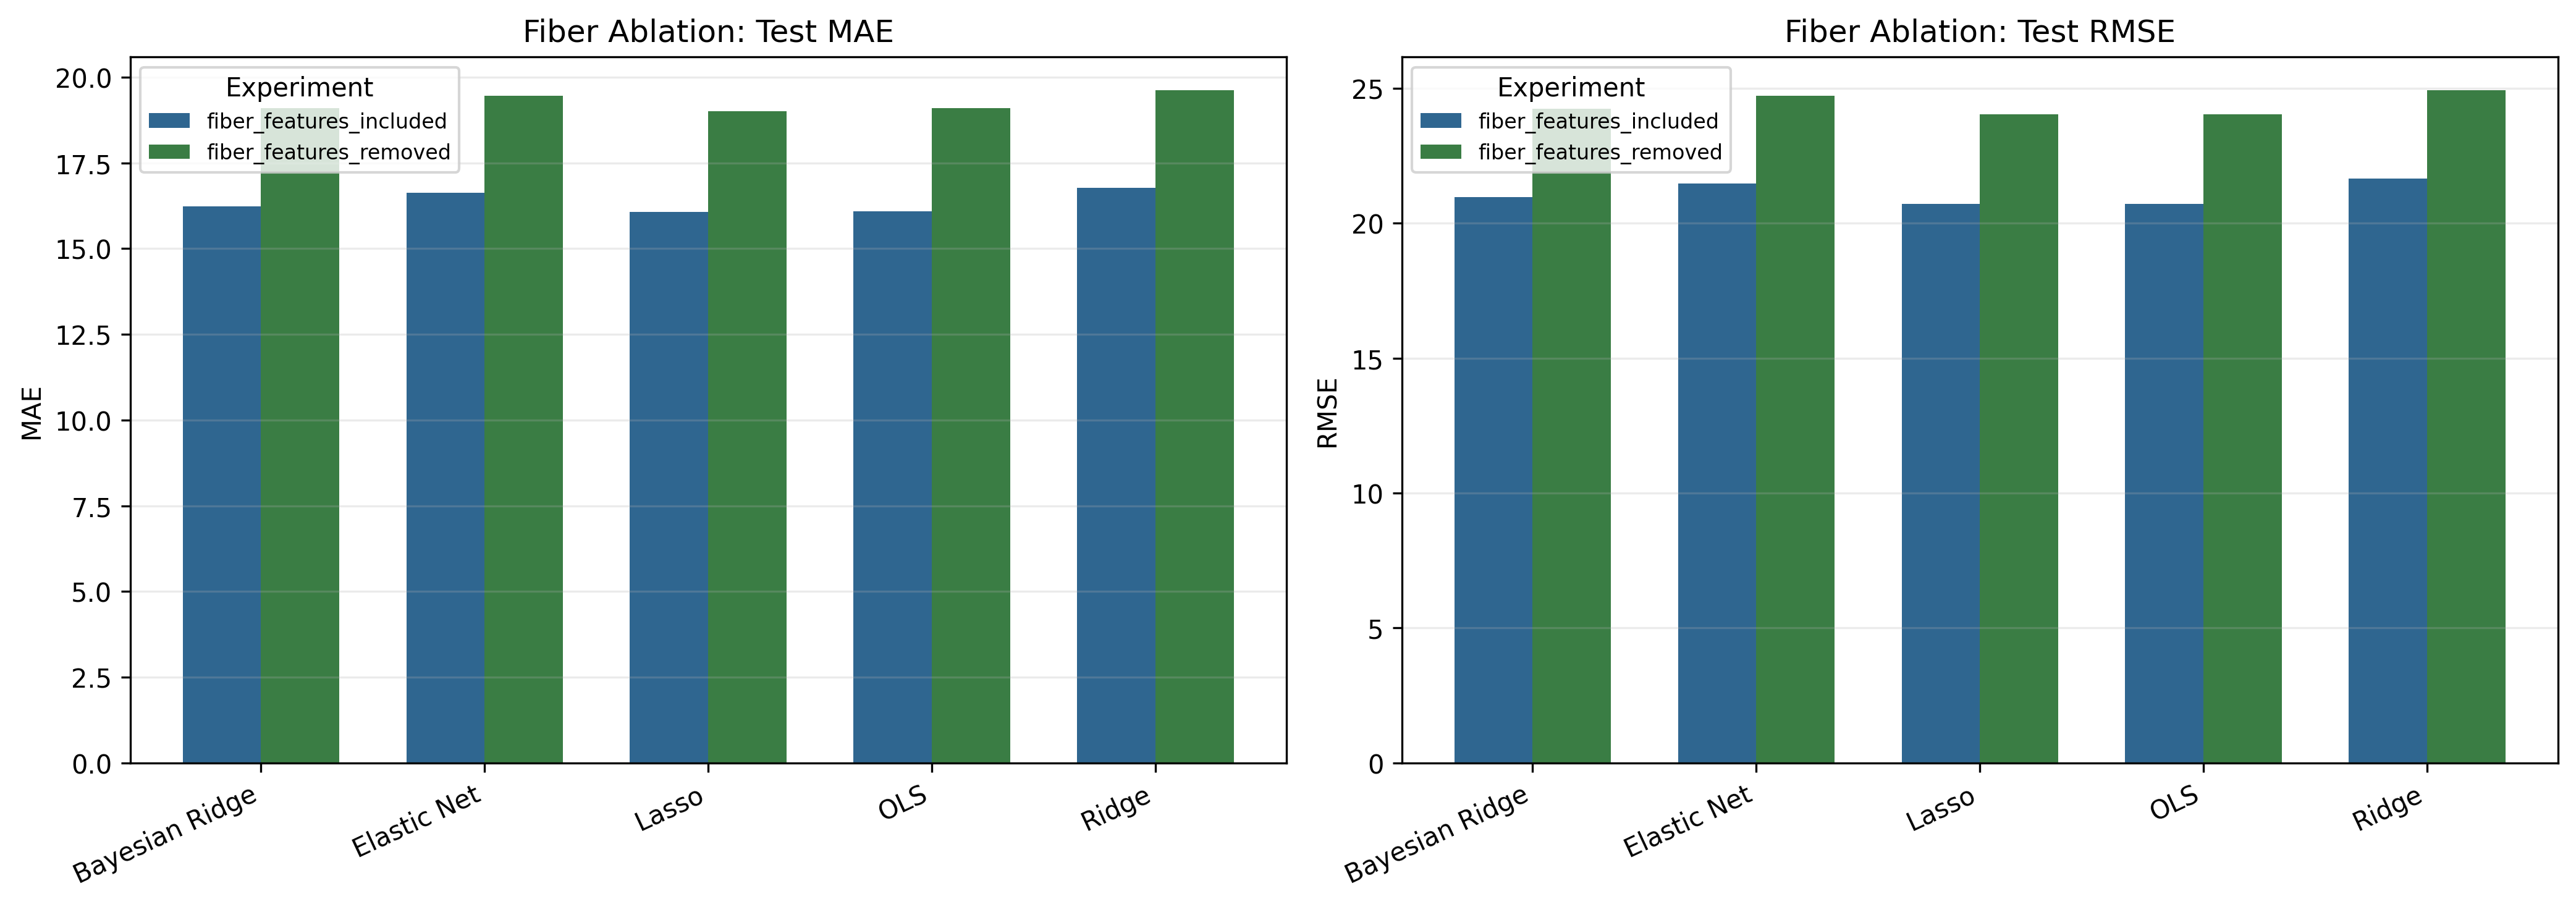

In [10]:
experiment_metrics = load_table("week07_targeted_experiment_metrics.csv")


def experiment_delta(family: str, reference: str, challenger: str) -> pd.DataFrame:
    test = experiment_metrics.query("split == 'test' and experiment_family == @family")
    wide = test.pivot_table(index="model", columns="experiment", values=["MAE", "RMSE", "R2"], aggfunc="mean")
    delta = pd.DataFrame({
        "model": wide.index,
        "delta_MAE": wide[("MAE", challenger)] - wide[("MAE", reference)],
        "delta_RMSE": wide[("RMSE", challenger)] - wide[("RMSE", reference)],
        "delta_R2": wide[("R2", challenger)] - wide[("R2", reference)],
    }).reset_index(drop=True)
    return delta.sort_values("delta_RMSE", ascending=False)


fiber_delta = experiment_delta("fiber_ablation", "fiber_features_included", "fiber_features_removed")
display(rounded(fiber_delta))
show_figure("week07_fiber_ablation_comparison.png", width=1100)

Removing fiber features worsens test RMSE by roughly 3.26 to 3.31 MPa across all models. The direction is consistent, not model-specific.

This is strong evidence that fiber features should stay in the Week 7 Linear Family dataset. The interpretation should still be cautious: the result does not mean fiber amount alone controls compressive strength. It means fiber-related variables carry predictive information in this dataset, probably through both material behavior and mix-design context.

## 12. Experiment: Outlier Sensitivity

This experiment removes target outliers from the **training set only** using the configured target quantiles. Validation and test sets remain unchanged.

This is important because removing validation/test outliers would make the evaluation artificially easier. The question is whether training on a trimmed target range improves generalization to the original distribution.

,lower_quantile,upper_quantile,lower_threshold,upper_threshold,training_rows_before,training_rows_after,training_rows_removed
45,0.025,0.975,91.5,230.0,1429.0,1360.0,69.0


,model,delta_MAE,delta_RMSE,delta_R2
0,Bayesian Ridge,0.832,1.242,-0.037
4,Ridge,0.713,1.021,-0.031
1,Elastic Net,0.682,1.001,-0.030
2,Lasso,0.481,0.957,-0.028
3,OLS,0.424,0.898,-0.026


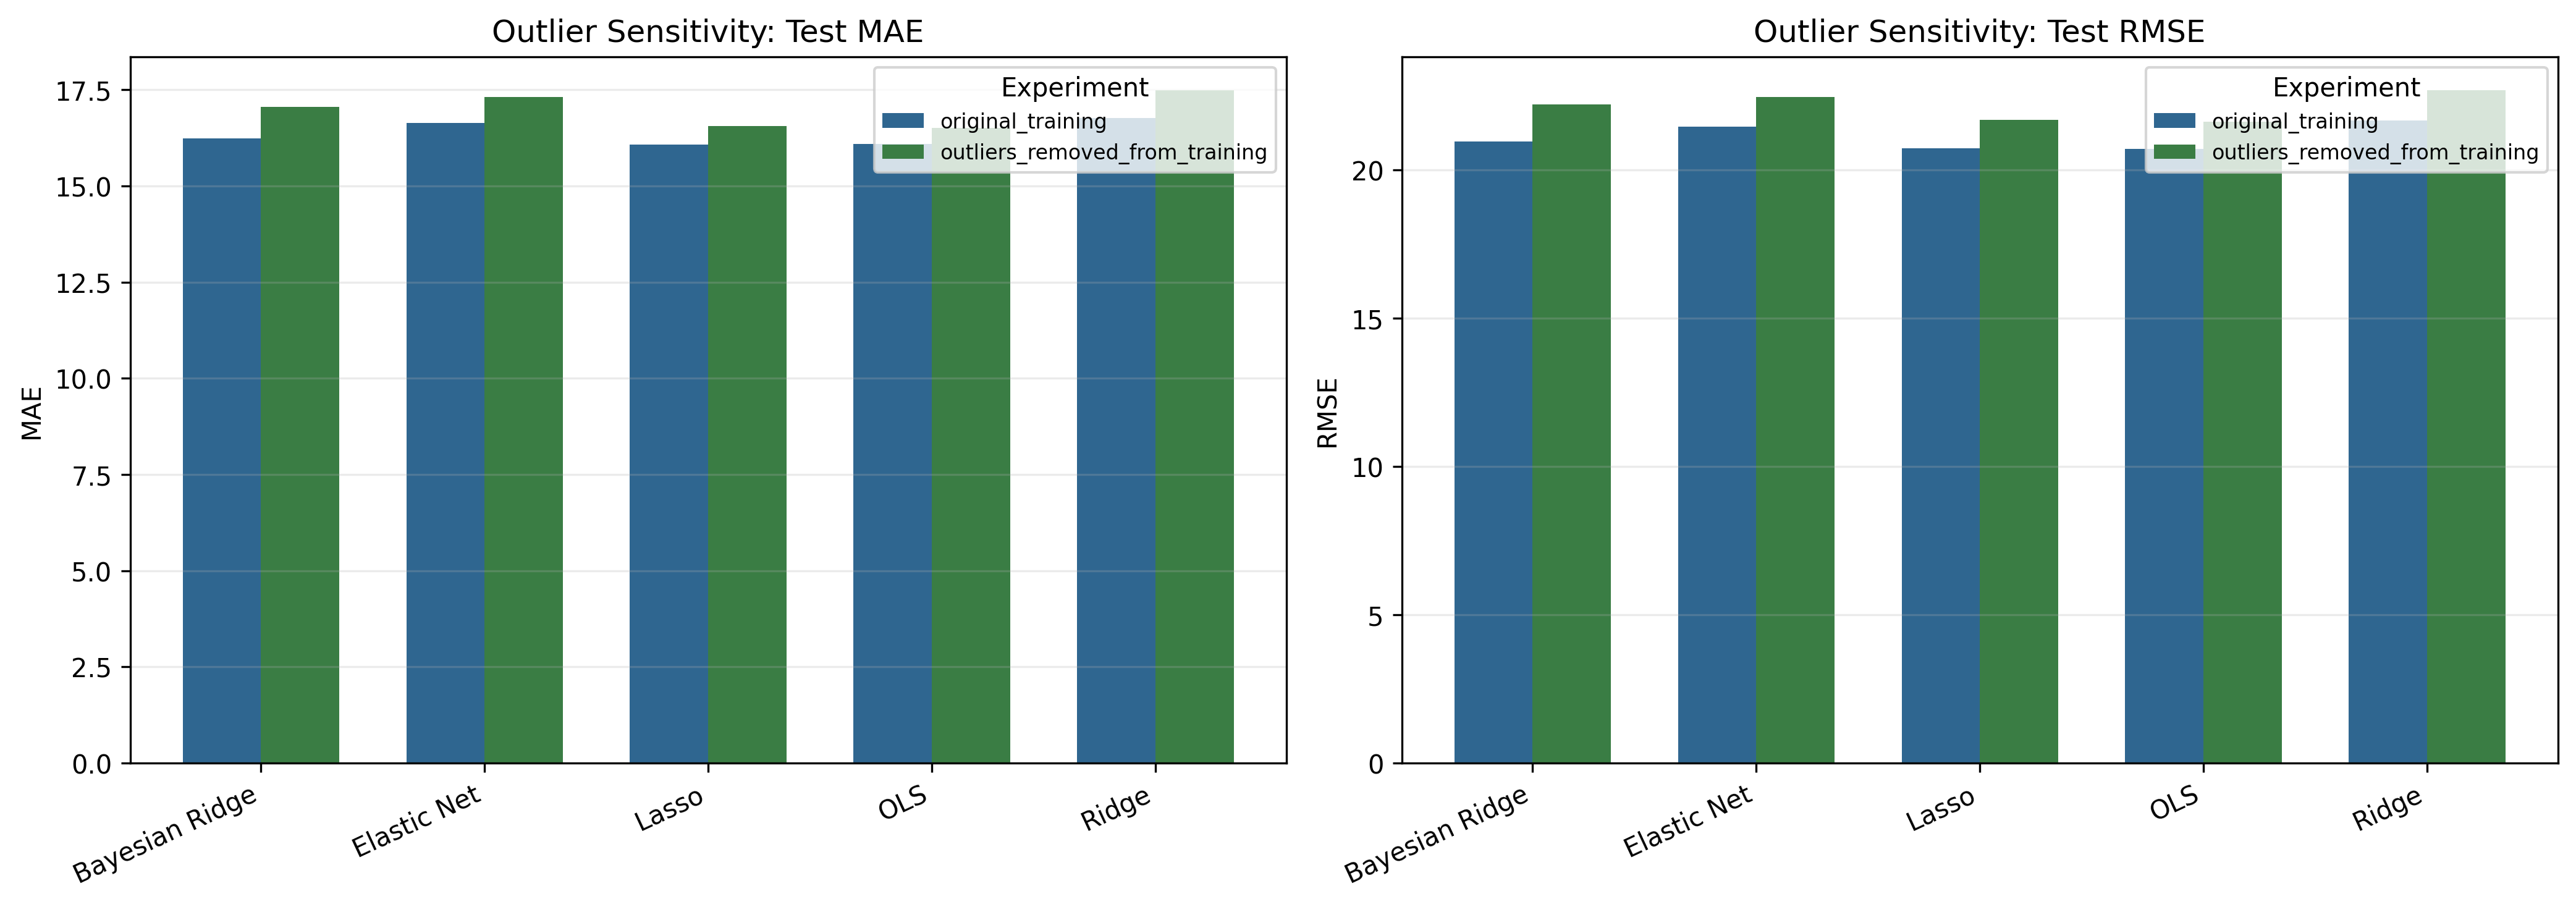

In [11]:
outlier_delta = experiment_delta("outlier_sensitivity", "original_training", "outliers_removed_from_training")
outlier_audit_cols = [
    "lower_quantile",
    "upper_quantile",
    "lower_threshold",
    "upper_threshold",
    "training_rows_before",
    "training_rows_after",
    "training_rows_removed",
]
outlier_audit = experiment_metrics.query("experiment == 'outliers_removed_from_training' and split == 'train'")[outlier_audit_cols].drop_duplicates()
display(rounded(outlier_audit))
display(rounded(outlier_delta))
show_figure("week07_outlier_sensitivity_comparison.png", width=1100)

Removing target outliers from training makes test RMSE worse by about 0.90 to 1.24 MPa, depending on the model. This suggests the extreme target values are not only noise. They contain useful information about real high-strength or low-strength UHPC regimes.

For this dataset, simply trimming the training target is not a good default. A better improvement path would be to investigate the large-error samples, check whether they come from specific curing methods or source studies, and possibly use robust losses or subgroup features rather than deleting them.

## 13. Experiment: Engineering Ratio Features, Exploratory

The engineering-feature experiment is marked exploratory because the final preprocessing dataset is not fixed yet. The idea is to add concrete-domain ratios such as water/binder ratio, SCM/binder ratio, sand/binder ratio, superplasticizer/binder ratio, and fiber/binder ratio.

One important design choice: when a combined amount is created, the raw amount components used to create it are removed in that experiment. Otherwise the model would see both `cement`, `slag`, etc. and `total_binder`, which can create redundant representations and make the interpretation less clean.

,model,delta_MAE,delta_RMSE,delta_R2
3,OLS,0.447,0.609,-0.018
2,Lasso,0.455,0.601,-0.017
4,Ridge,0.420,0.517,-0.016
1,Elastic Net,0.395,0.511,-0.015
0,Bayesian Ridge,0.360,0.469,-0.014


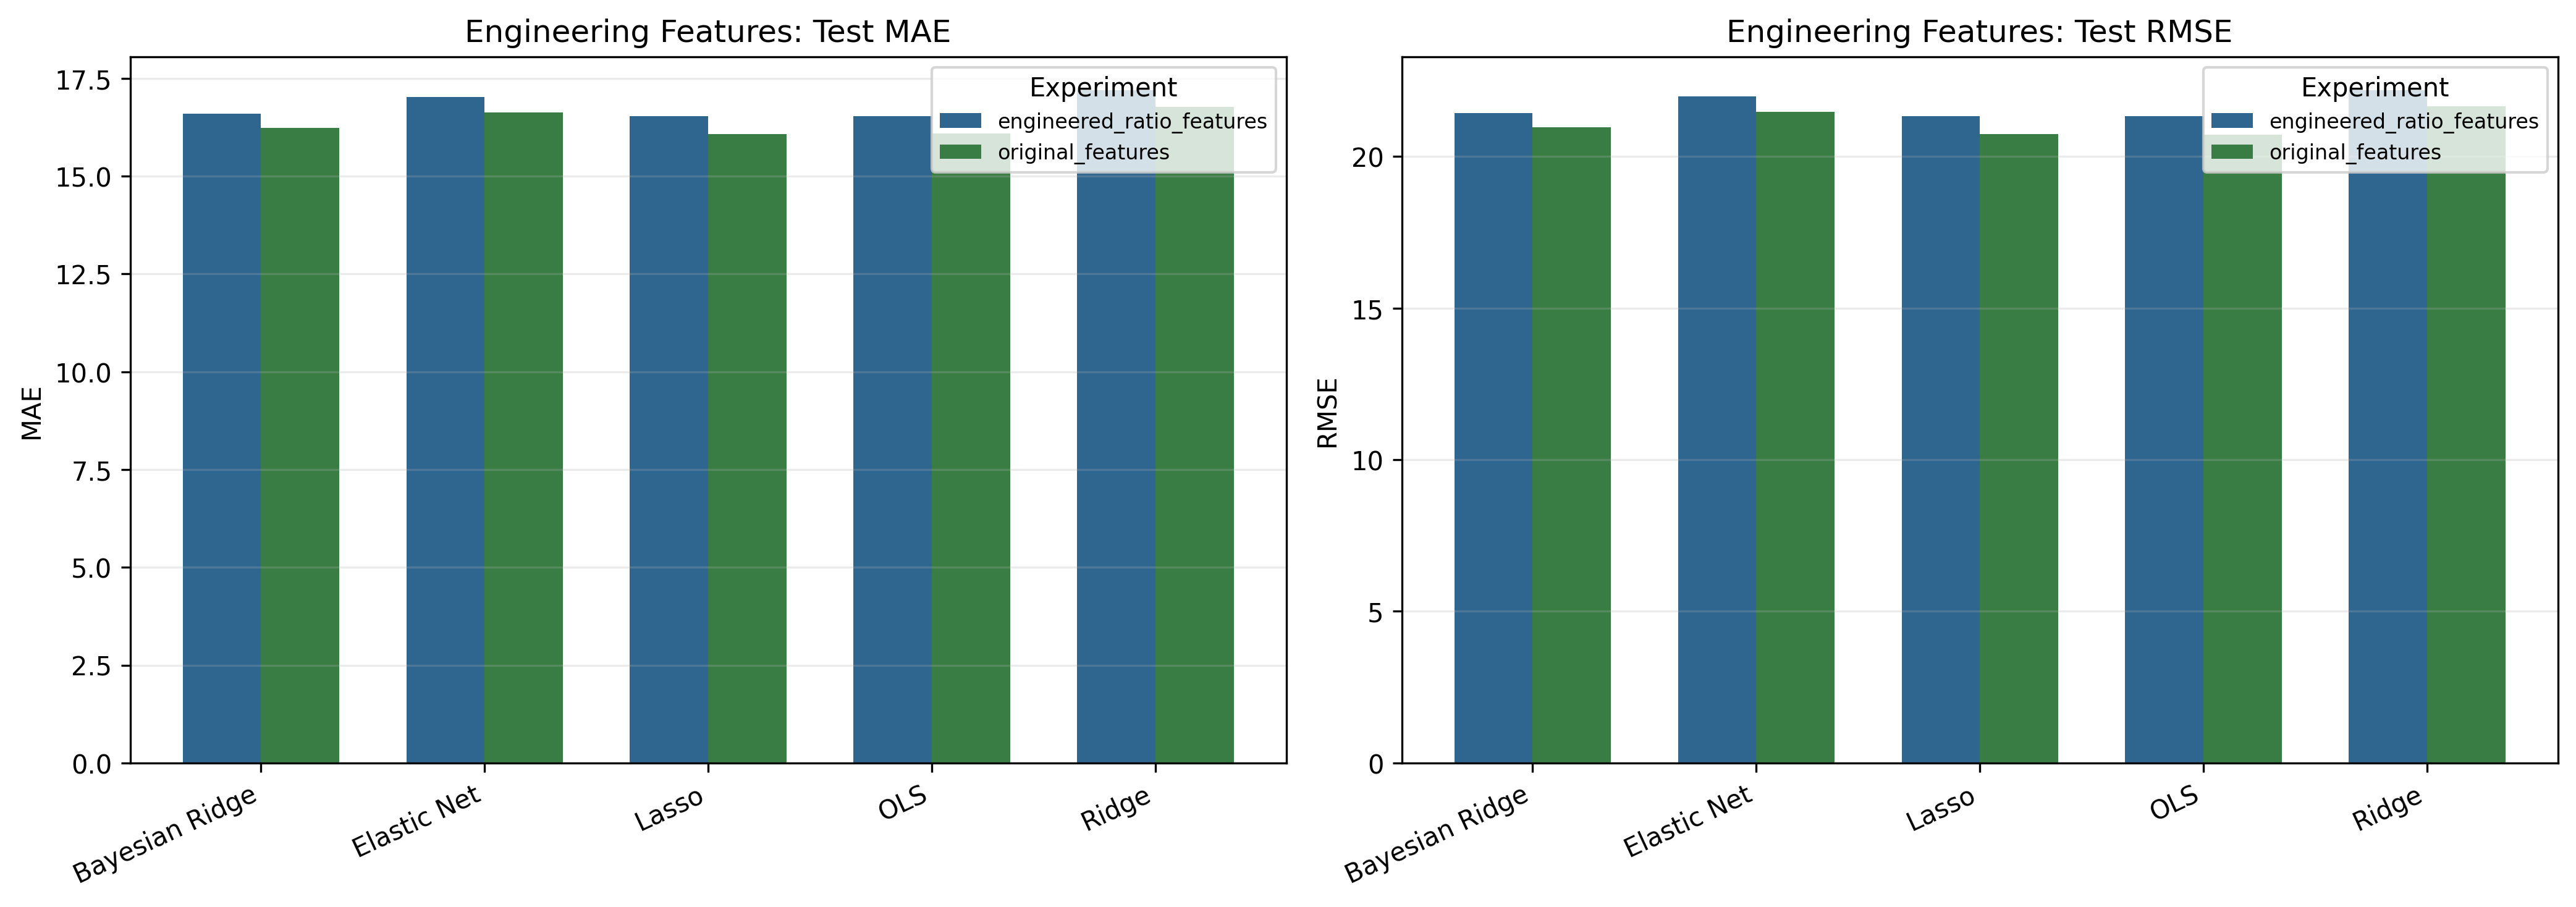

In [12]:
engineering_delta = experiment_delta("engineering_features", "original_features", "engineered_ratio_features")
display(rounded(engineering_delta))
show_figure("week07_engineering_features_comparison.png", width=1100)

The current engineering-ratio feature set slightly worsens test RMSE by about 0.47 to 0.61 MPa. This does not mean engineering features are useless. It means this first ratio set, under this fixed Linear Family setup, is not clearly better than the original semantic-recoded feature representation.

A reasonable next step is to keep this experiment exploratory and refine the feature engineering after the final dataset is fixed. For example, ratios may need better binder definitions, curing-aware interactions, or separate handling for missing material quantities.

## 14. Coefficient Diagnostic

The coefficient plot shows the largest positive and negative transformed-feature coefficients for the selected Lasso pipeline. These are not causal effects. They are model coefficients after scaling, missing indicators, and one-hot encoding.

Because VIF is low for numeric ingredients, numeric coefficient instability from multicollinearity is not the main concern here. The bigger caution is that one-hot category coefficients can reflect sparse category patterns, source-study effects, or dataset-specific reporting behavior.

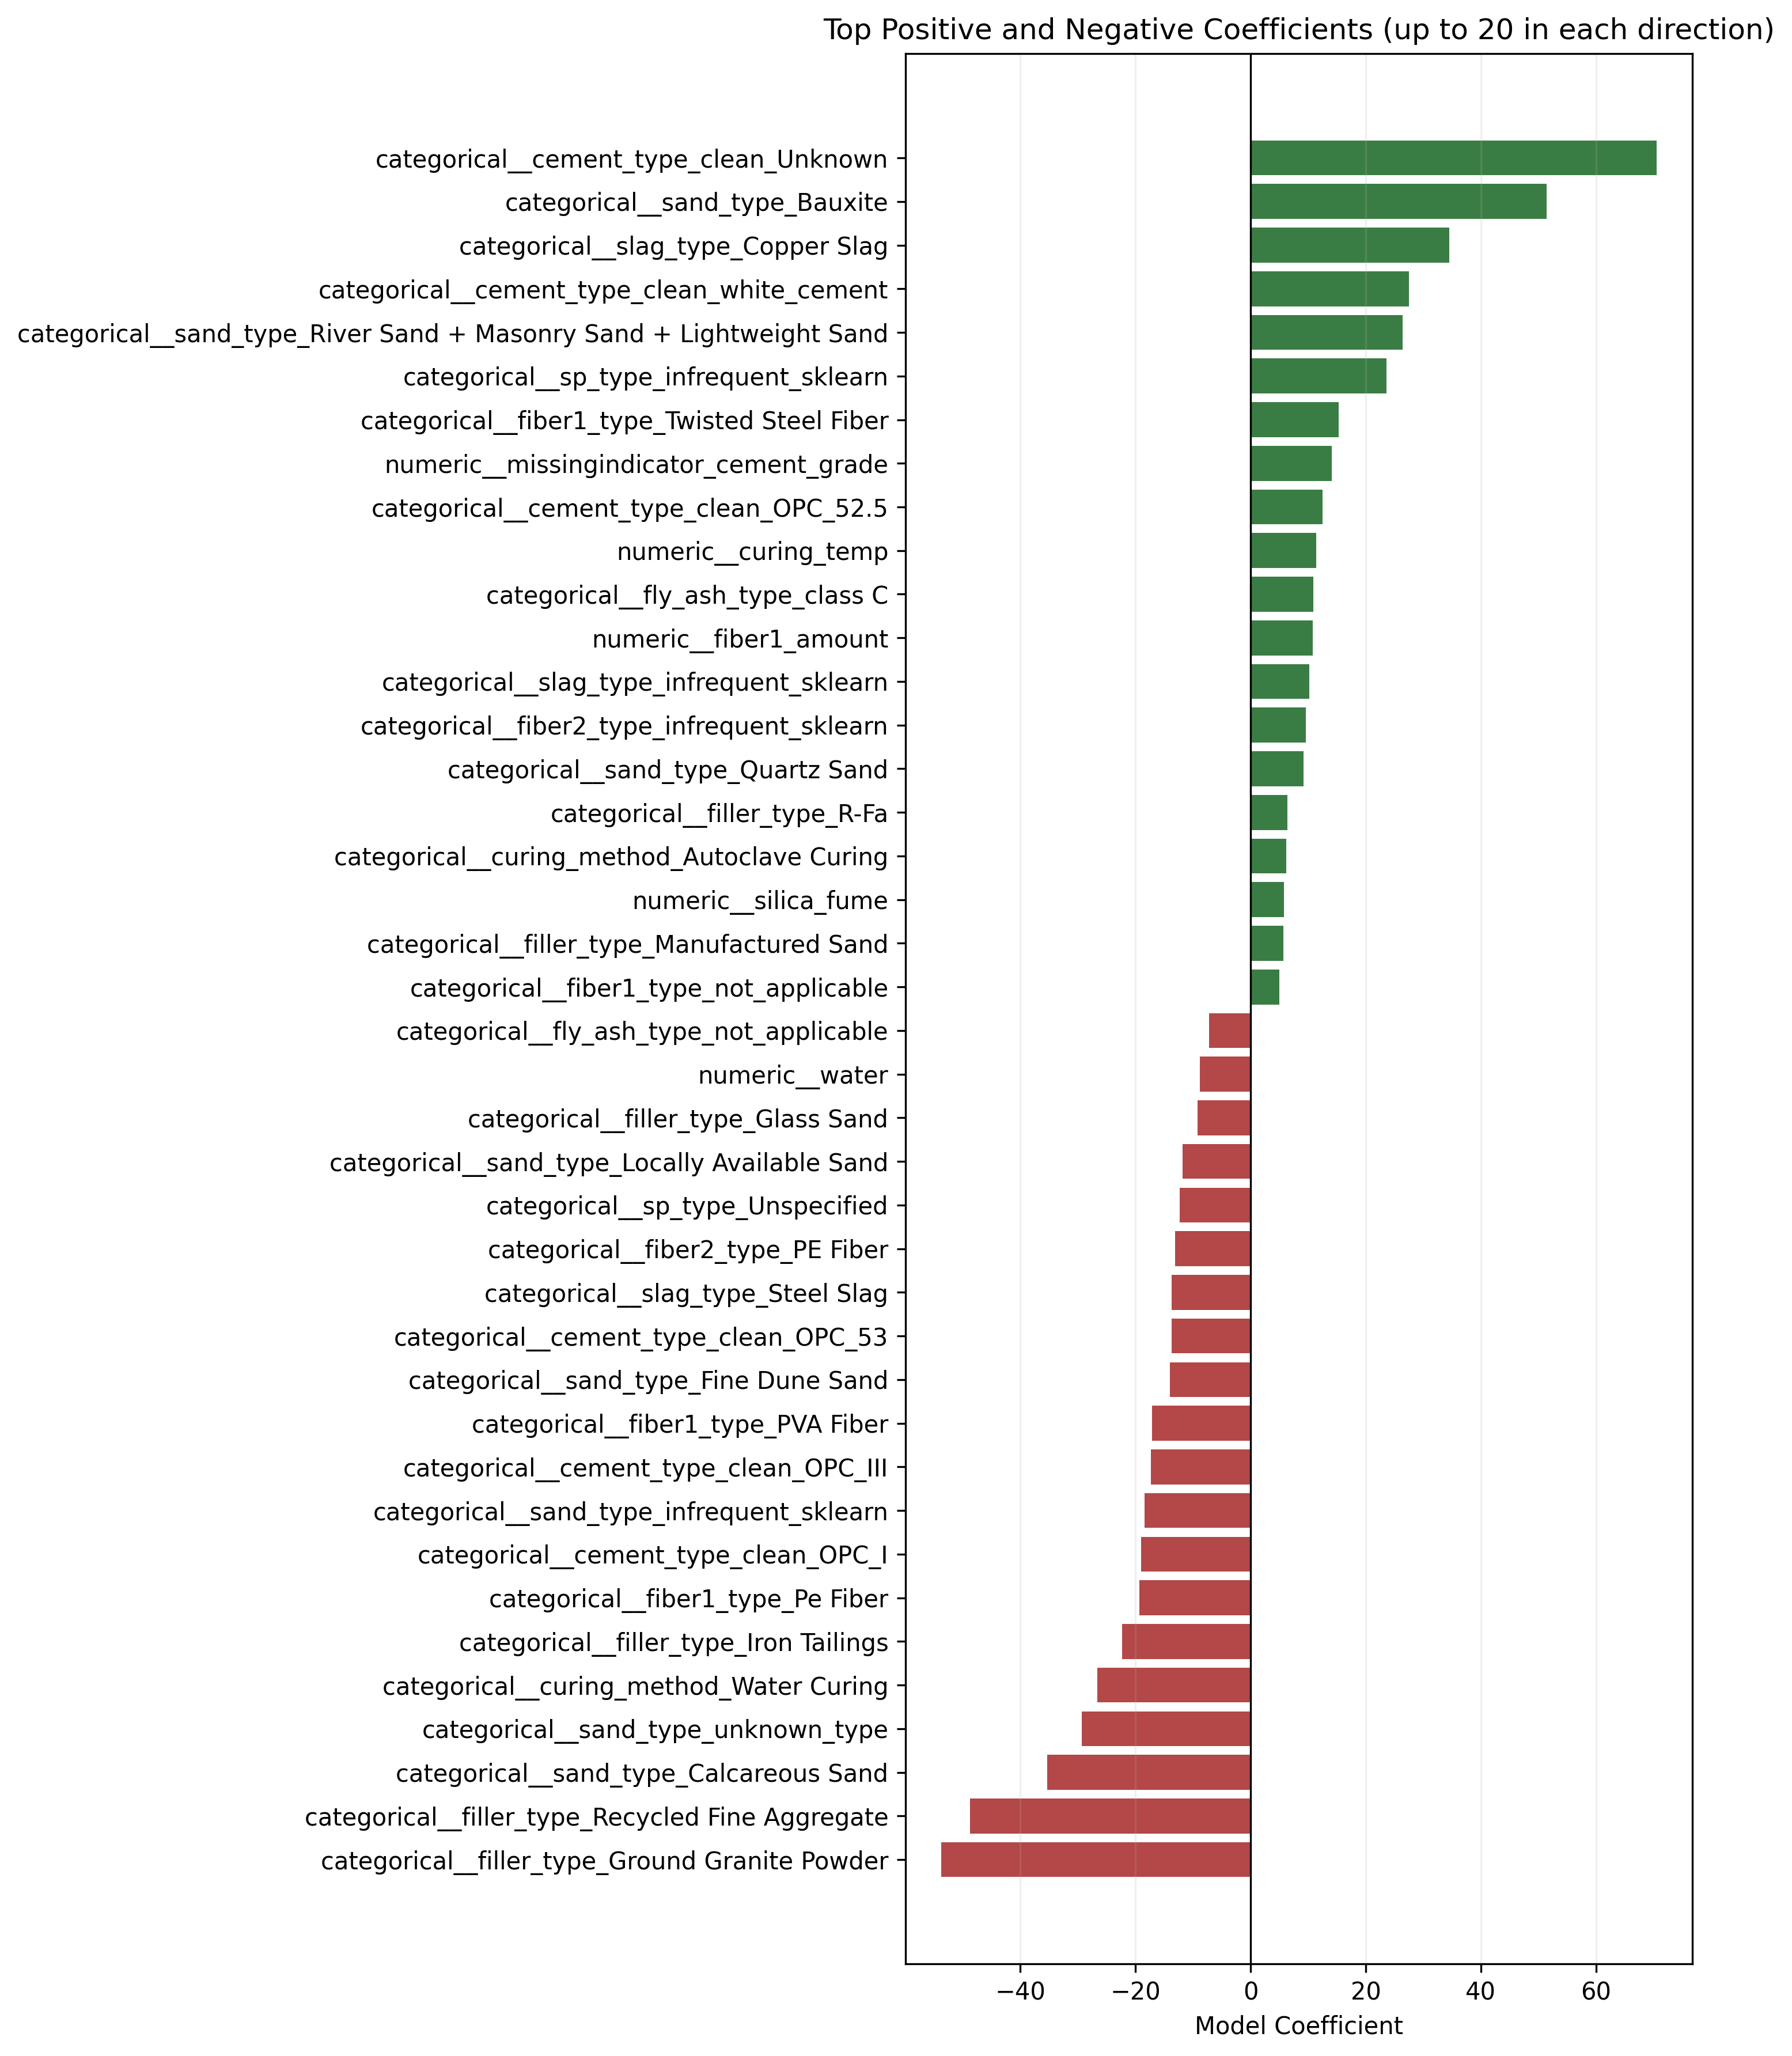

In [13]:
show_figure("week07_selected_baseline_coefficients.png", width=900)

## 15. What the Results Say About the Dataset

The current 50 percent semantic-recoded dataset is usable for Linear Family modeling. The pipeline can transform it without leakage, all transformed splits have zero remaining NaNs, and the selected Lasso baseline reaches a test R2 around 0.705.

However, the dataset still has important limitations:

- The source row count is one row lower than the expected raw count, and the import cannot restore rows already removed upstream.
- Mix ID and paper/source identifiers are unavailable, so the feature-hash grouping is only a partial leakage-control fallback.
- There are duplicate feature groups with conflicting targets, which suggests repeated or near-identical mixes may have different reported strengths.
- Special curing regimes, especially autoclave curing, show larger errors.
- Extreme low and high strength ranges show bias, so the model is strongest near the center of the target distribution.
- Fiber features are useful and should not be removed casually.
- Simple target-outlier trimming hurts test performance, which suggests the extremes contain real signal.
- The first engineering-ratio attempt does not improve test error, but it remains a useful exploratory direction.

## 16. How the Result Could Be Improved

The most useful improvements are probably dataset and feature improvements, not immediate hyperparameter tuning.

Recommended next steps:

- Preserve original paper/source IDs and mix IDs so grouped splitting can be stronger than feature hashing.
- Investigate high-error samples by curing method, strength range, and fiber group.
- Improve curing features, especially for heat, steam, and autoclave curing.
- Revisit engineering ratios after finalizing the dataset and binder definitions.
- Consider interaction terms between binder composition and curing regime if staying inside the Linear Family.
- Consider robust regression as a future Linear Family extension if outlier behavior remains important.
- After the dataset is fixed, tune regularization strength for Ridge, Lasso, and Elastic Net using validation or nested cross-validation.

For this week, the fixed-parameter setup is defendable because the assignment focuses on training, interpretation, sensitivity checks, and targeted experiments.

## 17. What I understood from this week's work

The baseline for this week is **Lasso on the semantic-recoded 50 percent dataset**, selected by validation RMSE. It gives approximately **20.73 MPa test RMSE**, **16.07 MPa test MAE**, and **0.705 test R2**.

The main interpretation is that the dataset supports a useful linear baseline, but errors are not uniform. The model underpredicts very high strengths and overpredicts lower strengths. Curing regime matters, with special curing groups showing higher errors than standard/normal curing. Fiber features are useful: removing them consistently worsens every model. Removing training target outliers also worsens performance, so the extremes should be investigated rather than deleted. Engineering ratio features are promising from a domain perspective, but the first implementation is exploratory and does not improve test RMSE.

VIF is low in the current numeric feature set, so severe numeric multicollinearity is not a major issue for this dataset. Still, coefficient interpretation should remain cautious because categorical one-hot features and missing indicators can be dataset-specific.